In [31]:
from pathlib import Path
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *
plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2


Loaded: 753 GC, 6795 NGS (no region filter)
Rendering 320° full brain…
Could not update the latest atlas versions cache: [Errno 13] Permission denied: '/Users/harryclark/.brainglobe/last_versions.conf'


Saving new screenshot at /tmp/mec_renders/full.png

Rendering 0° posterior clipped…
Could not update the latest atlas versions cache: [Errno 13] Permission denied: '/Users/harryclark/.brainglobe/last_versions.conf'


Saving new screenshot at /tmp/mec_renders/clip.png

Computing annotation overlays (100µm slices)…
  done


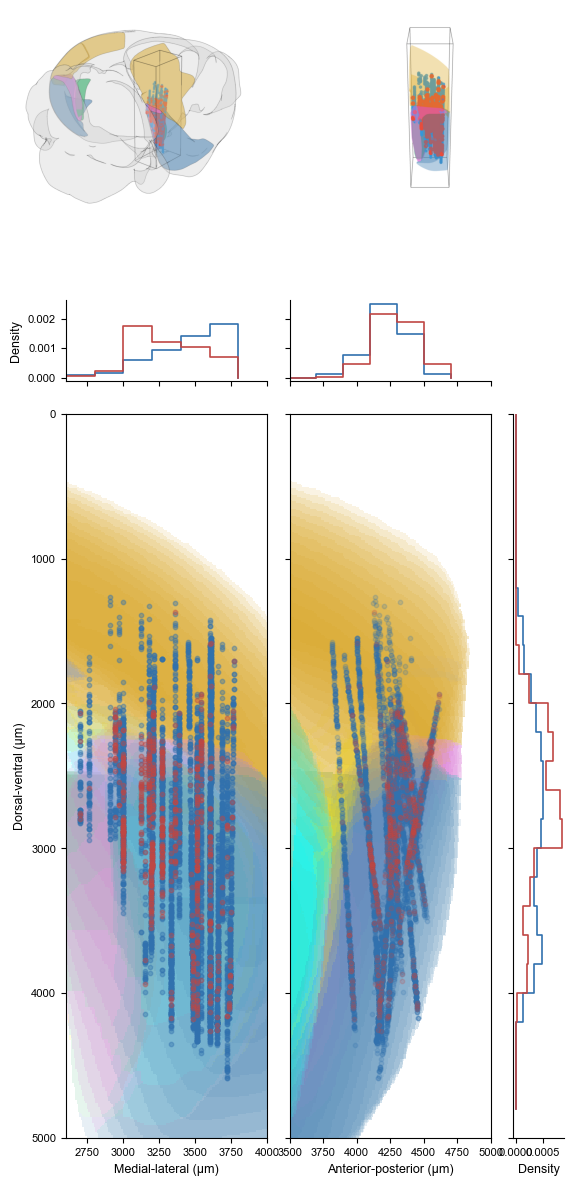

Saved → /Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/mec_overview_and_zoom.pdf


In [32]:
from brainrender import Scene, settings as br_settings
from brainrender.actors import Points
from brainrender.actor import Actor
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import ListedColormap, BoundaryNorm, to_rgba
import numpy as np
import pandas as pd
import math
from pathlib import Path
from vedo import Box as VedoBox
from tifffile import imread

br_settings.SHOW_AXES        = False
br_settings.BACKGROUND_COLOR = [1, 1, 1]

SAVE_DIR = Path('/tmp/mec_renders')
SAVE_DIR.mkdir(exist_ok=True)

annotations_set = imread('/Users/harryclark/.brainglobe/allen_mouse_10um_v1.2/annotation.tiff')
structure_set = pd.read_csv('/Users/harryclark/.brainglobe/allen_mouse_10um_v1.2/structures.csv')
id_to_acr = dict(zip(structure_set['id'], structure_set['acronym']))

TICK_SIZE  = 8
LABEL_SIZE = 9

def stereo_to_ccf(SC, angle=-0.0873):
    SC = np.asarray(SC, float)
    stretch = SC / np.array([1.0, 0.9434, 1.0])
    rotate = np.array([
        stretch[0]*math.cos(angle) - stretch[1]*math.sin(angle),
        stretch[0]*math.sin(angle) + stretch[1]*math.cos(angle),
        stretch[2]
    ])
    return rotate + np.array([5400.0, 440.0, 5700.0])

_df = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications_no_regions.csv')
_df = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications_no_regions.csv')
_df = _df[_df['mouse'] != 22]
_df['SC_x'] = -np.abs(_df['SC_x'])
_gc  = _df[_df['cell_type'] == 'GC'].dropna(subset=['SC_x', 'SC_y', 'SC_z'])
_ngs = _df[_df['cell_type'] == 'NG'].dropna(subset=['SC_x', 'SC_y', 'SC_z'])

print(f"Loaded: {len(_gc)} GC, {len(_ngs)} NGS (no region filter)")

def _df_to_ccf(d):
    return np.array([stereo_to_ccf(r) for r in d[['SC_z', 'SC_y', 'SC_x']].values])

gc_pts  = _df_to_ccf(_gc)
ngs_pts = _df_to_ccf(_ngs)

ml_gcs = -_gc['SC_x'].values;  ml_ngs = -_ngs['SC_x'].values
dv_gcs =  _gc['SC_y'].values;  dv_ngs =  _ngs['SC_y'].values
ap_gcs =  _gc['SC_z'].values;  ap_ngs =  _ngs['SC_z'].values

ML_LIM = (2600, 4000)
AP_LIM = (3500, 5000)
DV_LIM = (5000, 0)

corners_sc = np.array([
    [AP_LIM[0], min(DV_LIM), -ML_LIM[1]],
    [AP_LIM[0], min(DV_LIM), -ML_LIM[0]],
    [AP_LIM[0], max(DV_LIM), -ML_LIM[1]],
    [AP_LIM[0], max(DV_LIM), -ML_LIM[0]],
    [AP_LIM[1], min(DV_LIM), -ML_LIM[1]],
    [AP_LIM[1], min(DV_LIM), -ML_LIM[0]],
    [AP_LIM[1], max(DV_LIM), -ML_LIM[1]],
    [AP_LIM[1], max(DV_LIM), -ML_LIM[0]],
])
corners_ccf = np.array([stereo_to_ccf(c) for c in corners_sc])

bbox_min = corners_ccf.min(axis=0)
bbox_max = corners_ccf.max(axis=0)
bbox_center = (bbox_min + bbox_max) / 2
bbox_size   = bbox_max - bbox_min

FOCAL = (float(bbox_center[0]), float(bbox_center[1]), float(-bbox_center[2]))
rendered_bounds = [
    float(bbox_min[0]), float(bbox_max[0]),
    float(bbox_min[1]), float(bbox_max[1]),
    float(-bbox_max[2]), float(-bbox_min[2]),
]
bbox_center_rendered = (float(bbox_center[0]), float(bbox_center[1]), float(-bbox_center[2]))

def in_bbox(pts, bmin, bmax):
    return np.all((pts >= bmin) & (pts <= bmax), axis=1)

gc_box  = gc_pts[in_bbox(gc_pts, bbox_min, bbox_max)]
ngs_box = ngs_pts[in_bbox(ngs_pts, bbox_min, bbox_max)]

STRUCT_REGIONS = [
    ('ENT', 'steelblue',      0.40),
    ('PAR', 'orchid',         0.50),
    ('PRE', 'mediumseagreen', 0.50),
    ('VIS', 'goldenrod',      0.35),
]

R_horiz  = 35000
DV_ELEV  = -15000
R_close  = 12000
DV_close = -6000

# ── RENDER: 320° full brain ──────────────────────────────────────────────────
def build_full_scene():
    scene = Scene(root=True, atlas_name='allen_mouse_10um', title='')
    for rname, color, alpha in STRUCT_REGIONS:
        try:
            scene.add_brain_region(rname, alpha=alpha, color=color)
        except Exception as e:
            print(f'  skipped {rname}: {e}')
    box = VedoBox(pos=tuple(bbox_center),
                  length=float(bbox_size[0]),
                  width=float(bbox_size[1]),
                  height=float(bbox_size[2]))
    box.wireframe().c('black').lw(3).alpha(1.0)
    scene.add(Actor(box, name='bbox', br_class='mesh'))
    scene.add(Points(ngs_pts, name='NGS', colors='#3498db', radius=60, alpha=0.6))
    scene.add(Points(gc_pts,  name='GC',  colors='#e74c3c', radius=80, alpha=0.9))
    return scene

rad_320 = np.radians(320)
cam_full = {
    'pos':            (FOCAL[0] + R_horiz * np.cos(rad_320),
                       FOCAL[1] + DV_ELEV,
                       FOCAL[2] - R_horiz * np.sin(rad_320)),
    'focal_point':    FOCAL,
    'viewup':         (0, -1, 0),
    'clipping_range': (20000, 60000),
}

print("Rendering 320° full brain…")
scene = build_full_scene()
scene.render(camera=cam_full, interactive=False, zoom=2)
scene.screenshot(name=str(SAVE_DIR / 'full'), scale=2)
try:
    scene.close()
except Exception:
    pass
img_full = mpimg.imread(str(SAVE_DIR / 'full.png'))

# ── RENDER: 0° posterior clipped ──────────────────────────────────────────────
def build_clipped_scene():
    scene = Scene(root=False, atlas_name='allen_mouse_10um', title='')
    for rname, color, alpha in STRUCT_REGIONS:
        try:
            scene.add_brain_region(rname, alpha=alpha, color=color)
        except Exception as e:
            print(f'  skipped {rname}: {e}')
    if len(ngs_box) > 0:
        scene.add(Points(ngs_box, name='NGS', colors='#3498db', radius=60, alpha=0.6))
    if len(gc_box) > 0:
        scene.add(Points(gc_box,  name='GC',  colors='#e74c3c', radius=80, alpha=0.9))
    return scene

cam_clip = {
    'pos':            (FOCAL[0] + R_close, FOCAL[1] + DV_close, FOCAL[2]),
    'focal_point':    FOCAL,
    'viewup':         (0, -1, 0),
    'clipping_range': (5000, 25000),
}

print("Rendering 0° posterior clipped…")
scene = build_clipped_scene()
scene.render(camera=cam_clip, interactive=False, zoom=1)
for a in scene.plotter.objects:
    try:
        a.cut_with_box(rendered_bounds)
    except Exception:
        pass
box = VedoBox(pos=bbox_center_rendered,
              length=float(bbox_size[0]),
              width=float(bbox_size[1]),
              height=float(bbox_size[2]))
box.wireframe().c('black').lw(3).alpha(1.0)
scene.plotter.add(box)
scene.plotter.window.Render()
scene.screenshot(name=str(SAVE_DIR / 'clip'), scale=2)
try:
    scene.close()
except Exception:
    pass
img_clip = mpimg.imread(str(SAVE_DIR / 'clip.png'))

# ── ANNOTATION OVERLAYS (every 100µm) ────────────────────────────────────────
print("Computing annotation overlays (100µm slices)…")

step = 10
ml_axis = np.arange(ML_LIM[0] - 100, ML_LIM[1] + 100, step)
dv_axis = np.arange(min(DV_LIM) - 100, max(DV_LIM) + 100, step)
ap_axis = np.arange(AP_LIM[0] - 100, AP_LIM[1] + 100, step)

ap_slices = list(range(AP_LIM[0], AP_LIM[1] + 1, 100))
ml_slices = list(range(ML_LIM[0], ML_LIM[1] + 1, 100))

def _stereo_to_ccf_vec(ap, dv, ml, angle=-0.0873):
    cos_a, sin_a = math.cos(angle), math.sin(angle)
    s_dv = dv / 0.9434
    return (ap * cos_a - s_dv * sin_a + 5400.0,
            ap * sin_a + s_dv * cos_a + 440.0,
            ml + 5700.0)

def _ids_to_numeric(aid_flat):
    numeric = np.zeros(len(aid_flat), dtype=int)
    for sid in np.unique(aid_flat):
        if sid == 0:
            continue
        acr = id_to_acr.get(sid, 'root')
        m = aid_flat == sid
        if 'ENT' in acr:      numeric[m] = 1
        elif 'PAR' in acr:    numeric[m] = 2
        elif 'PRE' in acr:    numeric[m] = 3
        elif 'VIS' in acr:    numeric[m] = 4
        elif 'SUB' in acr:    numeric[m] = 5
        elif 'RSP' in acr:    numeric[m] = 6
        elif 'HPF' in acr:    numeric[m] = 7
    return numeric

def _lookup_slice_numeric(ccf_ap, ccf_dv, ccf_ml, shape_2d):
    zi = np.round(ccf_ap / 10).astype(int)
    yi = np.round(ccf_dv / 10).astype(int)
    xi = np.round(ccf_ml / 10).astype(int)
    sh = annotations_set.shape
    valid = (zi >= 0) & (zi < sh[0]) & (yi >= 0) & (yi < sh[1]) & (xi >= 0) & (xi < sh[2])
    aid = np.zeros(len(zi), dtype=int)
    aid[valid] = annotations_set[zi[valid], yi[valid], xi[valid]]
    return _ids_to_numeric(aid).reshape(shape_2d)

def get_ap_slice(ap_val):
    DV, ML = np.meshgrid(dv_axis, ml_axis, indexing='ij')
    c_ap, c_dv, c_ml = _stereo_to_ccf_vec(np.full(DV.size, ap_val), DV.ravel(), ML.ravel())
    return _lookup_slice_numeric(c_ap, c_dv, c_ml, DV.shape)

def get_ml_slice(ml_val):
    AP, DV = np.meshgrid(ap_axis, dv_axis, indexing='ij')
    c_ap, c_dv, c_ml = _stereo_to_ccf_vec(AP.ravel(), DV.ravel(), np.full(AP.size, ml_val))
    return _lookup_slice_numeric(c_ap, c_dv, c_ml, AP.shape)

print("  done")

cmap_list = [(1, 1, 1, 0)]
for name in ['steelblue', 'orchid', 'mediumseagreen', 'goldenrod', 'cyan', 'grey', 'yellow']:
    r, g, b, _ = to_rgba(name)
    cmap_list.append((r, g, b, 0.125))
region_cmap = ListedColormap(cmap_list)
region_norm = BoundaryNorm(np.arange(-0.5, 8.5, 1), region_cmap.N)

# ── FIGURE ────────────────────────────────────────────────────────────────────
DATA_ASPECT = (max(DV_LIM) - min(DV_LIM)) / (ML_LIM[1] - ML_LIM[0])
HIST_W = 0.25
HIST_H = 0.4

fig_w = 6
bot_panel_w = 0.85 * fig_w
bot_panel_h = bot_panel_w * (HIST_H + DATA_ASPECT) / (2 + HIST_W)
brain_h = 3.0
fig_h = brain_h + 0.4 + bot_panel_h

brain_top = 0.98
brain_bot = brain_top - brain_h / fig_h
bot_top = brain_bot - 0.4 / fig_h
bot_bot = 0.03

fig = plt.figure(figsize=(fig_w, fig_h))

top_gs = fig.add_gridspec(1, 2, wspace=0.02,
                          left=0.05, right=0.95, top=brain_top, bottom=brain_bot)
fig.add_subplot(top_gs[0]).imshow(img_full); fig.axes[-1].axis('off')
fig.add_subplot(top_gs[1]).imshow(img_clip); fig.axes[-1].axis('off')

bot_gs = fig.add_gridspec(
    2, 3,
    width_ratios=[1, 1, HIST_W],
    height_ratios=[HIST_H, DATA_ASPECT],
    wspace=0.15, hspace=0.08,
    left=0.12, right=0.95, top=bot_top, bottom=bot_bot,
)

ax_ml_dv = fig.add_subplot(bot_gs[1, 0])
ax_ap_dv = fig.add_subplot(bot_gs[1, 1], sharey=ax_ml_dv)
ax_ml_h  = fig.add_subplot(bot_gs[0, 0], sharex=ax_ml_dv)
ax_ap_h  = fig.add_subplot(bot_gs[0, 1], sharex=ax_ap_dv, sharey=ax_ml_h)
ax_dv_h  = fig.add_subplot(bot_gs[1, 2], sharey=ax_ml_dv)
ax_blank = fig.add_subplot(bot_gs[0, 2])

# ── ML vs DV ─────────────────────────────────────────────────────────────────
for ap_val in ap_slices:
    s = get_ap_slice(ap_val)
    ax_ml_dv.pcolormesh(ml_axis, dv_axis, s,
                        cmap=region_cmap, norm=region_norm,
                        shading='nearest', rasterized=True)
ax_ml_dv.scatter(ml_ngs, dv_ngs, color='#3171ae', alpha=0.4, s=10, zorder=2)
ax_ml_dv.scatter(ml_gcs, dv_gcs, color='#c04744', alpha=0.4, s=10, zorder=2)
ax_ml_dv.set_xlim(ML_LIM)
ax_ml_dv.set_ylim(DV_LIM)
ax_ml_dv.set_xlabel('Medial-lateral (µm)', fontsize=LABEL_SIZE)
ax_ml_dv.set_ylabel('Dorsal-ventral (µm)', fontsize=LABEL_SIZE)
ax_ml_dv.tick_params(labelsize=TICK_SIZE)

# ── AP vs DV ─────────────────────────────────────────────────────────────────
for ml_val in ml_slices:
    s = get_ml_slice(ml_val)
    ax_ap_dv.pcolormesh(ap_axis, dv_axis, s.T,
                        cmap=region_cmap, norm=region_norm,
                        shading='nearest', rasterized=True)
ax_ap_dv.scatter(ap_ngs, dv_ngs, color='#3171ae', alpha=0.2, s=10, zorder=2)
ax_ap_dv.scatter(ap_gcs, dv_gcs, color='#c04744', alpha=0.2, s=10, zorder=2)
ax_ap_dv.set_xlim(AP_LIM)
ax_ap_dv.set_xlabel('Anterior-posterior (µm)', fontsize=LABEL_SIZE)
ax_ap_dv.tick_params(labelleft=False, labelsize=TICK_SIZE)

# ── ML density ────────────────────────────────────────────────────────────────
ml_bins = np.arange(ML_LIM[0], ML_LIM[1] + 1, 200)
ax_ml_h.step(ml_bins[:-1], np.histogram(ml_ngs, ml_bins, density=True)[0],
             where='post', color='#3171ae', lw=1.2)
ax_ml_h.step(ml_bins[:-1], np.histogram(ml_gcs, ml_bins, density=True)[0],
             where='post', color='#c04744', lw=1.2)
ax_ml_h.set_ylabel('Density', fontsize=LABEL_SIZE)
ax_ml_h.tick_params(labelbottom=False, labelsize=TICK_SIZE)
ax_ml_h.spines[['top', 'right']].set_visible(False)

# ── AP density ────────────────────────────────────────────────────────────────
ap_bins = np.arange(AP_LIM[0], AP_LIM[1] + 1, 200)
ax_ap_h.step(ap_bins[:-1], np.histogram(ap_ngs, ap_bins, density=True)[0],
             where='post', color='#3171ae', lw=1.2)
ax_ap_h.step(ap_bins[:-1], np.histogram(ap_gcs, ap_bins, density=True)[0],
             where='post', color='#c04744', lw=1.2)
ax_ap_h.tick_params(labelbottom=False, labelleft=False, labelsize=TICK_SIZE)
ax_ap_h.spines[['top', 'right']].set_visible(False)

# ── DV density (horizontal) ──────────────────────────────────────────────────
dv_bins = np.arange(min(DV_LIM), max(DV_LIM) + 1, 200)
ax_dv_h.step(np.histogram(dv_ngs, dv_bins, density=True)[0], dv_bins[:-1],
             where='post', color='#3171ae', lw=1.2)
ax_dv_h.step(np.histogram(dv_gcs, dv_bins, density=True)[0], dv_bins[:-1],
             where='post', color='#c04744', lw=1.2)
ax_dv_h.set_xlabel('Density', fontsize=LABEL_SIZE)
ax_dv_h.tick_params(labelleft=False, labelsize=TICK_SIZE)
ax_dv_h.spines[['top', 'right']].set_visible(False)

ax_blank.axis('off')

out_path = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/mec_overview_and_zoom.pdf'
plt.savefig(out_path, bbox_inches='tight', dpi=600)
plt.show()
print(f"Saved → {out_path}")


Loaded: 753 GC total (201 both sessions, 552 either only), 6795 NGS
  classified_by values: {'OF1': 294, 'OF2': 258, 'both': 201}
Rendering 320° full brain…
Could not update the latest atlas versions cache: [Errno 13] Permission denied: '/Users/harryclark/.brainglobe/last_versions.conf'


Saving new screenshot at /tmp/mec_renders/full.png

Rendering 0° posterior clipped…
Could not update the latest atlas versions cache: [Errno 13] Permission denied: '/Users/harryclark/.brainglobe/last_versions.conf'


Saving new screenshot at /tmp/mec_renders/clip.png

Computing annotation overlays (100µm slices)…
  done


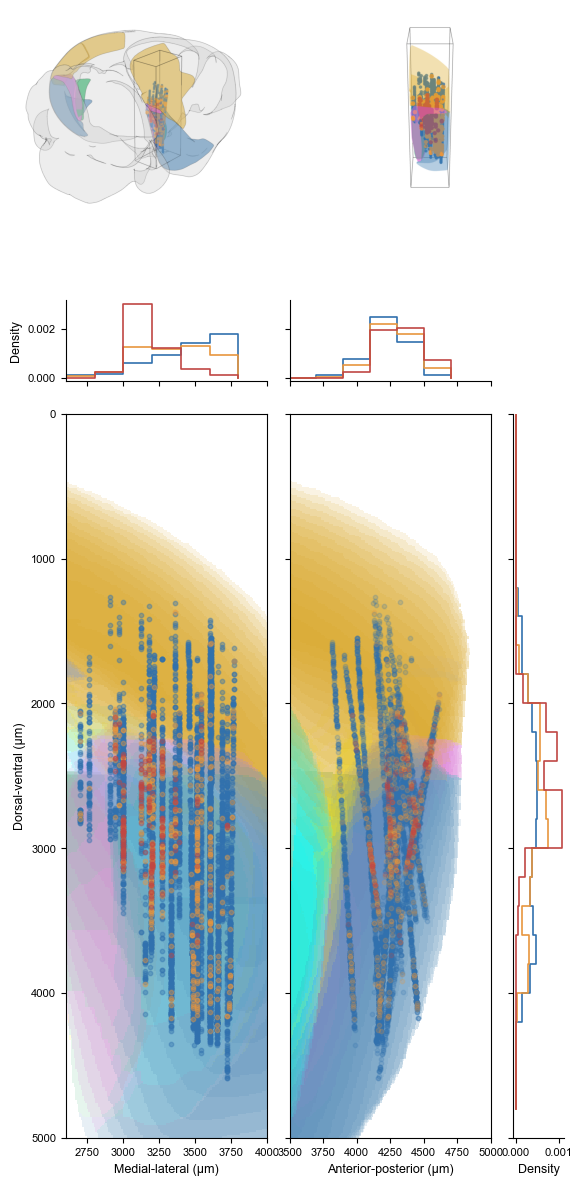

Saved → /Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/mec_overview_gc_sessions.pdf


In [33]:
from brainrender import Scene, settings as br_settings
from brainrender.actors import Points
from brainrender.actor import Actor
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import ListedColormap, BoundaryNorm, to_rgba
import numpy as np
import pandas as pd
import math
from pathlib import Path
from vedo import Box as VedoBox
from tifffile import imread

br_settings.SHOW_AXES        = False
br_settings.BACKGROUND_COLOR = [1, 1, 1]

SAVE_DIR = Path('/tmp/mec_renders')
SAVE_DIR.mkdir(exist_ok=True)

annotations_set = imread('/Users/harryclark/.brainglobe/allen_mouse_10um_v1.2/annotation.tiff')
structure_set = pd.read_csv('/Users/harryclark/.brainglobe/allen_mouse_10um_v1.2/structures.csv')
id_to_acr = dict(zip(structure_set['id'], structure_set['acronym']))

TICK_SIZE  = 8
LABEL_SIZE = 9

def stereo_to_ccf(SC, angle=-0.0873):
    SC = np.asarray(SC, float)
    stretch = SC / np.array([1.0, 0.9434, 1.0])
    rotate = np.array([
        stretch[0]*math.cos(angle) - stretch[1]*math.sin(angle),
        stretch[0]*math.sin(angle) + stretch[1]*math.cos(angle),
        stretch[2]
    ])
    return rotate + np.array([5400.0, 440.0, 5700.0])

_df = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications_no_regions.csv')
_df = _df[_df['mouse'] != 22]
_df['SC_x'] = -np.abs(_df['SC_x'])

_gc_all = _df[_df['cell_type'] == 'GC'].dropna(subset=['SC_x', 'SC_y', 'SC_z'])
_ngs    = _df[_df['cell_type'] == 'NG'].dropna(subset=['SC_x', 'SC_y', 'SC_z'])

# Split GCs by classified_by: OF1 or OF2 = either session, anything else = both sessions
_gc_either = _gc_all[_gc_all['classified_by'].isin(['OF1', 'OF2'])]
_gc_both   = _gc_all[~_gc_all['classified_by'].isin(['OF1', 'OF2'])]

print(f"Loaded: {len(_gc_all)} GC total ({len(_gc_both)} both sessions, {len(_gc_either)} either only), {len(_ngs)} NGS")
print(f"  classified_by values: {_gc_all['classified_by'].value_counts().to_dict()}")

def _df_to_ccf(d):
    return np.array([stereo_to_ccf(r) for r in d[['SC_z', 'SC_y', 'SC_x']].values])

gc_both_pts   = _df_to_ccf(_gc_both)   if len(_gc_both) > 0   else np.empty((0,3))
gc_either_pts = _df_to_ccf(_gc_either) if len(_gc_either) > 0 else np.empty((0,3))
ngs_pts       = _df_to_ccf(_ngs)

ml_gc_both = -_gc_both['SC_x'].values;   ml_gc_either = -_gc_either['SC_x'].values;   ml_ngs = -_ngs['SC_x'].values
dv_gc_both =  _gc_both['SC_y'].values;   dv_gc_either =  _gc_either['SC_y'].values;   dv_ngs =  _ngs['SC_y'].values
ap_gc_both =  _gc_both['SC_z'].values;   ap_gc_either =  _gc_either['SC_z'].values;   ap_ngs =  _ngs['SC_z'].values

ML_LIM = (2600, 4000)
AP_LIM = (3500, 5000)
DV_LIM = (5000, 0)

corners_sc = np.array([
    [AP_LIM[0], min(DV_LIM), -ML_LIM[1]],
    [AP_LIM[0], min(DV_LIM), -ML_LIM[0]],
    [AP_LIM[0], max(DV_LIM), -ML_LIM[1]],
    [AP_LIM[0], max(DV_LIM), -ML_LIM[0]],
    [AP_LIM[1], min(DV_LIM), -ML_LIM[1]],
    [AP_LIM[1], min(DV_LIM), -ML_LIM[0]],
    [AP_LIM[1], max(DV_LIM), -ML_LIM[1]],
    [AP_LIM[1], max(DV_LIM), -ML_LIM[0]],
])
corners_ccf = np.array([stereo_to_ccf(c) for c in corners_sc])

bbox_min = corners_ccf.min(axis=0)
bbox_max = corners_ccf.max(axis=0)
bbox_center = (bbox_min + bbox_max) / 2
bbox_size   = bbox_max - bbox_min

FOCAL = (float(bbox_center[0]), float(bbox_center[1]), float(-bbox_center[2]))
rendered_bounds = [
    float(bbox_min[0]), float(bbox_max[0]),
    float(bbox_min[1]), float(bbox_max[1]),
    float(-bbox_max[2]), float(-bbox_min[2]),
]
bbox_center_rendered = (float(bbox_center[0]), float(bbox_center[1]), float(-bbox_center[2]))

def in_bbox(pts, bmin, bmax):
    return np.all((pts >= bmin) & (pts <= bmax), axis=1)

gc_both_box   = gc_both_pts[in_bbox(gc_both_pts, bbox_min, bbox_max)]     if len(gc_both_pts) > 0   else np.empty((0,3))
gc_either_box = gc_either_pts[in_bbox(gc_either_pts, bbox_min, bbox_max)] if len(gc_either_pts) > 0 else np.empty((0,3))
ngs_box       = ngs_pts[in_bbox(ngs_pts, bbox_min, bbox_max)]

STRUCT_REGIONS = [
    ('ENT', 'steelblue',      0.40),
    ('PAR', 'orchid',         0.50),
    ('PRE', 'mediumseagreen', 0.50),
    ('VIS', 'goldenrod',      0.35),
]

R_horiz  = 35000
DV_ELEV  = -15000
R_close  = 12000
DV_close = -6000

COL_BOTH   = '#c04744'
COL_EITHER = '#e8963e'
COL_NGS    = '#3171ae'

# ── RENDER: 320° full brain ──────────────────────────────────────────────────
def build_full_scene():
    scene = Scene(root=True, atlas_name='allen_mouse_10um', title='')
    for rname, color, alpha in STRUCT_REGIONS:
        try:
            scene.add_brain_region(rname, alpha=alpha, color=color)
        except Exception as e:
            print(f'  skipped {rname}: {e}')
    box = VedoBox(pos=tuple(bbox_center),
                  length=float(bbox_size[0]),
                  width=float(bbox_size[1]),
                  height=float(bbox_size[2]))
    box.wireframe().c('black').lw(3).alpha(1.0)
    scene.add(Actor(box, name='bbox', br_class='mesh'))
    scene.add(Points(ngs_pts, name='NGS', colors=COL_NGS, radius=60, alpha=0.6))
    if len(gc_either_pts) > 0:
        scene.add(Points(gc_either_pts, name='GC_either', colors=COL_EITHER, radius=80, alpha=0.8))
    if len(gc_both_pts) > 0:
        scene.add(Points(gc_both_pts, name='GC_both', colors=COL_BOTH, radius=80, alpha=0.9))
    return scene

rad_320 = np.radians(320)
cam_full = {
    'pos':            (FOCAL[0] + R_horiz * np.cos(rad_320),
                       FOCAL[1] + DV_ELEV,
                       FOCAL[2] - R_horiz * np.sin(rad_320)),
    'focal_point':    FOCAL,
    'viewup':         (0, -1, 0),
    'clipping_range': (20000, 60000),
}

print("Rendering 320° full brain…")
scene = build_full_scene()
scene.render(camera=cam_full, interactive=False, zoom=2)
scene.screenshot(name=str(SAVE_DIR / 'full'), scale=2)
try:
    scene.close()
except Exception:
    pass
img_full = mpimg.imread(str(SAVE_DIR / 'full.png'))

# ── RENDER: 0° posterior clipped ──────────────────────────────────────────────
def build_clipped_scene():
    scene = Scene(root=False, atlas_name='allen_mouse_10um', title='')
    for rname, color, alpha in STRUCT_REGIONS:
        try:
            scene.add_brain_region(rname, alpha=alpha, color=color)
        except Exception as e:
            print(f'  skipped {rname}: {e}')
    if len(ngs_box) > 0:
        scene.add(Points(ngs_box, name='NGS', colors=COL_NGS, radius=60, alpha=0.6))
    if len(gc_either_box) > 0:
        scene.add(Points(gc_either_box, name='GC_either', colors=COL_EITHER, radius=80, alpha=0.8))
    if len(gc_both_box) > 0:
        scene.add(Points(gc_both_box, name='GC_both', colors=COL_BOTH, radius=80, alpha=0.9))
    return scene

cam_clip = {
    'pos':            (FOCAL[0] + R_close, FOCAL[1] + DV_close, FOCAL[2]),
    'focal_point':    FOCAL,
    'viewup':         (0, -1, 0),
    'clipping_range': (5000, 25000),
}

print("Rendering 0° posterior clipped…")
scene = build_clipped_scene()
scene.render(camera=cam_clip, interactive=False, zoom=1)
for a in scene.plotter.objects:
    try:
        a.cut_with_box(rendered_bounds)
    except Exception:
        pass
box = VedoBox(pos=bbox_center_rendered,
              length=float(bbox_size[0]),
              width=float(bbox_size[1]),
              height=float(bbox_size[2]))
box.wireframe().c('black').lw(3).alpha(1.0)
scene.plotter.add(box)
scene.plotter.window.Render()
scene.screenshot(name=str(SAVE_DIR / 'clip'), scale=2)
try:
    scene.close()
except Exception:
    pass
img_clip = mpimg.imread(str(SAVE_DIR / 'clip.png'))

# ── ANNOTATION OVERLAYS (every 100µm) ────────────────────────────────────────
print("Computing annotation overlays (100µm slices)…")

step = 10
ml_axis = np.arange(ML_LIM[0] - 100, ML_LIM[1] + 100, step)
dv_axis = np.arange(min(DV_LIM) - 100, max(DV_LIM) + 100, step)
ap_axis = np.arange(AP_LIM[0] - 100, AP_LIM[1] + 100, step)

ap_slices = list(range(AP_LIM[0], AP_LIM[1] + 1, 100))
ml_slices = list(range(ML_LIM[0], ML_LIM[1] + 1, 100))

def _stereo_to_ccf_vec(ap, dv, ml, angle=-0.0873):
    cos_a, sin_a = math.cos(angle), math.sin(angle)
    s_dv = dv / 0.9434
    return (ap * cos_a - s_dv * sin_a + 5400.0,
            ap * sin_a + s_dv * cos_a + 440.0,
            ml + 5700.0)

def _ids_to_numeric(aid_flat):
    numeric = np.zeros(len(aid_flat), dtype=int)
    for sid in np.unique(aid_flat):
        if sid == 0:
            continue
        acr = id_to_acr.get(sid, 'root')
        m = aid_flat == sid
        if 'ENT' in acr:      numeric[m] = 1
        elif 'PAR' in acr:    numeric[m] = 2
        elif 'PRE' in acr:    numeric[m] = 3
        elif 'VIS' in acr:    numeric[m] = 4
        elif 'SUB' in acr:    numeric[m] = 5
        elif 'RSP' in acr:    numeric[m] = 6
        elif 'HPF' in acr:    numeric[m] = 7
    return numeric

def _lookup_slice_numeric(ccf_ap, ccf_dv, ccf_ml, shape_2d):
    zi = np.round(ccf_ap / 10).astype(int)
    yi = np.round(ccf_dv / 10).astype(int)
    xi = np.round(ccf_ml / 10).astype(int)
    sh = annotations_set.shape
    valid = (zi >= 0) & (zi < sh[0]) & (yi >= 0) & (yi < sh[1]) & (xi >= 0) & (xi < sh[2])
    aid = np.zeros(len(zi), dtype=int)
    aid[valid] = annotations_set[zi[valid], yi[valid], xi[valid]]
    return _ids_to_numeric(aid).reshape(shape_2d)

def get_ap_slice(ap_val):
    DV, ML = np.meshgrid(dv_axis, ml_axis, indexing='ij')
    c_ap, c_dv, c_ml = _stereo_to_ccf_vec(np.full(DV.size, ap_val), DV.ravel(), ML.ravel())
    return _lookup_slice_numeric(c_ap, c_dv, c_ml, DV.shape)

def get_ml_slice(ml_val):
    AP, DV = np.meshgrid(ap_axis, dv_axis, indexing='ij')
    c_ap, c_dv, c_ml = _stereo_to_ccf_vec(AP.ravel(), DV.ravel(), np.full(AP.size, ml_val))
    return _lookup_slice_numeric(c_ap, c_dv, c_ml, AP.shape)

print("  done")

cmap_list = [(1, 1, 1, 0)]
for name in ['steelblue', 'orchid', 'mediumseagreen', 'goldenrod', 'cyan', 'grey', 'yellow']:
    r, g, b, _ = to_rgba(name)
    cmap_list.append((r, g, b, 0.125))
region_cmap = ListedColormap(cmap_list)
region_norm = BoundaryNorm(np.arange(-0.5, 8.5, 1), region_cmap.N)

# ── FIGURE ────────────────────────────────────────────────────────────────────
DATA_ASPECT = (max(DV_LIM) - min(DV_LIM)) / (ML_LIM[1] - ML_LIM[0])
HIST_W = 0.25
HIST_H = 0.4

fig_w = 6
bot_panel_w = 0.85 * fig_w
bot_panel_h = bot_panel_w * (HIST_H + DATA_ASPECT) / (2 + HIST_W)
brain_h = 3.0
fig_h = brain_h + 0.4 + bot_panel_h

brain_top = 0.98
brain_bot = brain_top - brain_h / fig_h
bot_top = brain_bot - 0.4 / fig_h
bot_bot = 0.03

fig = plt.figure(figsize=(fig_w, fig_h))

top_gs = fig.add_gridspec(1, 2, wspace=0.02,
                          left=0.05, right=0.95, top=brain_top, bottom=brain_bot)
fig.add_subplot(top_gs[0]).imshow(img_full); fig.axes[-1].axis('off')
fig.add_subplot(top_gs[1]).imshow(img_clip); fig.axes[-1].axis('off')

bot_gs = fig.add_gridspec(
    2, 3,
    width_ratios=[1, 1, HIST_W],
    height_ratios=[HIST_H, DATA_ASPECT],
    wspace=0.15, hspace=0.08,
    left=0.12, right=0.95, top=bot_top, bottom=bot_bot,
)

ax_ml_dv = fig.add_subplot(bot_gs[1, 0])
ax_ap_dv = fig.add_subplot(bot_gs[1, 1], sharey=ax_ml_dv)
ax_ml_h  = fig.add_subplot(bot_gs[0, 0], sharex=ax_ml_dv)
ax_ap_h  = fig.add_subplot(bot_gs[0, 1], sharex=ax_ap_dv, sharey=ax_ml_h)
ax_dv_h  = fig.add_subplot(bot_gs[1, 2], sharey=ax_ml_dv)
ax_blank = fig.add_subplot(bot_gs[0, 2])

# ── ML vs DV ─────────────────────────────────────────────────────────────────
for ap_val in ap_slices:
    s = get_ap_slice(ap_val)
    ax_ml_dv.pcolormesh(ml_axis, dv_axis, s,
                        cmap=region_cmap, norm=region_norm,
                        shading='nearest', rasterized=True)
ax_ml_dv.scatter(ml_ngs, dv_ngs, color=COL_NGS, alpha=0.4, s=10, zorder=2)
ax_ml_dv.scatter(ml_gc_either, dv_gc_either, color=COL_EITHER, alpha=0.4, s=10, zorder=3)
ax_ml_dv.scatter(ml_gc_both, dv_gc_both, color=COL_BOTH, alpha=0.4, s=10, zorder=4)
ax_ml_dv.set_xlim(ML_LIM)
ax_ml_dv.set_ylim(DV_LIM)
ax_ml_dv.set_xlabel('Medial-lateral (µm)', fontsize=LABEL_SIZE)
ax_ml_dv.set_ylabel('Dorsal-ventral (µm)', fontsize=LABEL_SIZE)
ax_ml_dv.tick_params(labelsize=TICK_SIZE)

# ── AP vs DV ─────────────────────────────────────────────────────────────────
for ml_val in ml_slices:
    s = get_ml_slice(ml_val)
    ax_ap_dv.pcolormesh(ap_axis, dv_axis, s.T,
                        cmap=region_cmap, norm=region_norm,
                        shading='nearest', rasterized=True)
ax_ap_dv.scatter(ap_ngs, dv_ngs, color=COL_NGS, alpha=0.2, s=10, zorder=2)
ax_ap_dv.scatter(ap_gc_either, dv_gc_either, color=COL_EITHER, alpha=0.2, s=10, zorder=3)
ax_ap_dv.scatter(ap_gc_both, dv_gc_both, color=COL_BOTH, alpha=0.2, s=10, zorder=4)
ax_ap_dv.set_xlim(AP_LIM)
ax_ap_dv.set_xlabel('Anterior-posterior (µm)', fontsize=LABEL_SIZE)
ax_ap_dv.tick_params(labelleft=False, labelsize=TICK_SIZE)

# ── ML density ────────────────────────────────────────────────────────────────
ml_bins = np.arange(ML_LIM[0], ML_LIM[1] + 1, 200)
ax_ml_h.step(ml_bins[:-1], np.histogram(ml_ngs, ml_bins, density=True)[0],
             where='post', color=COL_NGS, lw=1.2)
ax_ml_h.step(ml_bins[:-1], np.histogram(ml_gc_either, ml_bins, density=True)[0],
             where='post', color=COL_EITHER, lw=1.2)
ax_ml_h.step(ml_bins[:-1], np.histogram(ml_gc_both, ml_bins, density=True)[0],
             where='post', color=COL_BOTH, lw=1.2)
ax_ml_h.set_ylabel('Density', fontsize=LABEL_SIZE)
ax_ml_h.tick_params(labelbottom=False, labelsize=TICK_SIZE)
ax_ml_h.spines[['top', 'right']].set_visible(False)

# ── AP density ────────────────────────────────────────────────────────────────
ap_bins = np.arange(AP_LIM[0], AP_LIM[1] + 1, 200)
ax_ap_h.step(ap_bins[:-1], np.histogram(ap_ngs, ap_bins, density=True)[0],
             where='post', color=COL_NGS, lw=1.2)
ax_ap_h.step(ap_bins[:-1], np.histogram(ap_gc_either, ap_bins, density=True)[0],
             where='post', color=COL_EITHER, lw=1.2)
ax_ap_h.step(ap_bins[:-1], np.histogram(ap_gc_both, ap_bins, density=True)[0],
             where='post', color=COL_BOTH, lw=1.2)
ax_ap_h.tick_params(labelbottom=False, labelleft=False, labelsize=TICK_SIZE)
ax_ap_h.spines[['top', 'right']].set_visible(False)

# ── DV density (horizontal) ──────────────────────────────────────────────────
dv_bins = np.arange(min(DV_LIM), max(DV_LIM) + 1, 200)
ax_dv_h.step(np.histogram(dv_ngs, dv_bins, density=True)[0], dv_bins[:-1],
             where='post', color=COL_NGS, lw=1.2)
ax_dv_h.step(np.histogram(dv_gc_either, dv_bins, density=True)[0], dv_bins[:-1],
             where='post', color=COL_EITHER, lw=1.2)
ax_dv_h.step(np.histogram(dv_gc_both, dv_bins, density=True)[0], dv_bins[:-1],
             where='post', color=COL_BOTH, lw=1.2)
ax_dv_h.set_xlabel('Density', fontsize=LABEL_SIZE)
ax_dv_h.tick_params(labelleft=False, labelsize=TICK_SIZE)
ax_dv_h.spines[['top', 'right']].set_visible(False)

ax_blank.axis('off')

out_path = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/mec_overview_gc_sessions.pdf'
plt.savefig(out_path, bbox_inches='tight', dpi=600)
plt.show()
print(f"Saved → {out_path}")


In [42]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

_cc = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')
_cc = _cc[_cc['mouse'] != 22]

gc_both   = _cc[(_cc['cell_type'] == 'GC') & (_cc['classified_by'] == 'both')]
gc_either = _cc[(_cc['cell_type'] == 'GC') & (_cc['classified_by'].isin(['OF1', 'OF2']))]
ngs       = _cc[_cc['cell_type'] == 'NG']

mouse_ids = np.sort(_cc['mouse'].dropna().unique().astype(int))

device_contacts = pd.read_csv('/Users/harryclark/Downloads/device_contact_id_annotations.csv')
device_contacts = device_contacts[device_contacts['mouse'] != 22]
ent_contacts = device_contacts[device_contacts['brain_region'].str.contains('ENT', case=False, na=False)]

ml_bins = np.arange(2600, 4001, 100)
ap_bins = np.arange(3500, 5001, 100)
dv_bins = np.arange(0, 5001, 100)

print(f"Cells: {len(gc_both)} GC(both), {len(gc_either)} GC(either), {len(ngs)} NGS | ENT contacts: {len(ent_contacts)}")

n_mice = len(mouse_ids)
groups = {
    'GC_both': gc_both,
    'GC_either': gc_either,
    'NGS': ngs,
}

coord_fns = {
    'ML': (lambda df: np.abs(df['SC_x']),      lambda df: np.abs(df['coord_SCs_x'])),
    'AP': (lambda df: df['SC_z'],               lambda df: df['coord_SCs_z']),
    'DV': (lambda df: df['SC_y'],               lambda df: df['coord_SCs_y']),
}

def compute_per_mouse_hist(group_dfs, contact_df, coord_fn_cells, coord_fn_contacts, bins):
    n_bins = len(bins) - 1
    hists = {name: np.full((n_mice, n_bins), np.nan) for name in group_dfs}

    for i_mouse, mouse in enumerate(mouse_ids):
        contacts_mouse = contact_df[contact_df['mouse'] == mouse]
        contact_counts, _ = np.histogram(coord_fn_contacts(contacts_mouse), bins=bins)

        for name, df in group_dfs.items():
            cells_mouse = df[df['mouse'] == mouse]
            cell_counts, _ = np.histogram(coord_fn_cells(cells_mouse), bins=bins)
            hists[name][i_mouse] = np.divide(cell_counts, contact_counts,
                                              out=np.full(n_bins, np.nan), where=contact_counts > 0)
    return hists

def uniformity_glmm_per_group(group_dfs, contact_df, coord_fn_cells, coord_fn_contacts, bins, axis_label):
    pvals = {}
    for group_name, cell_df in group_dfs.items():
        data = []
        for mouse in mouse_ids:
            contacts_mouse = contact_df[contact_df['mouse'] == mouse]
            contact_counts, _ = np.histogram(coord_fn_contacts(contacts_mouse), bins=bins)

            days = cell_df[cell_df['mouse'] == mouse]['day'].dropna().unique()
            for day in days:
                cells_day = cell_df[(cell_df['mouse'] == mouse) & (cell_df['day'] == day)]
                cell_counts, _ = np.histogram(coord_fn_cells(cells_day), bins=bins)

                for i_bin in range(len(bins) - 1):
                    if contact_counts[i_bin] > 0:
                        data.append({
                            'value': cell_counts[i_bin] / contact_counts[i_bin],
                            'bin': float(bins[i_bin]),
                            'mouse': int(mouse),
                            'session': f"{int(mouse)}_{int(day)}",
                        })

        df = pd.DataFrame(data)
        if len(df) < 10:
            print(f"  {axis_label} {group_name}: skipped (too few observations)")
            pvals[group_name] = np.nan
            continue

        df['bin_z'] = (df['bin'] - df['bin'].mean()) / df['bin'].std()

        try:
            model = smf.mixedlm(
                "value ~ bin_z", df,
                groups=df["mouse"],
                vc_formula={"session": "0 + C(session)"},
            )
            result = model.fit(method="powell", maxiter=5000, disp=False)
            p = result.pvalues.get('bin_z', np.nan)
            print(f"  {axis_label} {group_name}: bin_z p = {p:.4g}")
            pvals[group_name] = p
        except Exception as e:
            print(f"  {axis_label} {group_name}: GLMM failed ({e})")
            pvals[group_name] = np.nan

    return pvals

cell_fn_ml, contact_fn_ml = coord_fns['ML']
cell_fn_ap, contact_fn_ap = coord_fns['AP']
cell_fn_dv, contact_fn_dv = coord_fns['DV']

hists_ml = compute_per_mouse_hist(groups, ent_contacts, cell_fn_ml, contact_fn_ml, ml_bins)
hists_ap = compute_per_mouse_hist(groups, ent_contacts, cell_fn_ap, contact_fn_ap, ap_bins)
hists_dv = compute_per_mouse_hist(groups, ent_contacts, cell_fn_dv, contact_fn_dv, dv_bins)

print("\nUniformity GLMMs (H0: uniform distribution along axis):")
pvals_ml = uniformity_glmm_per_group(groups, ent_contacts, cell_fn_ml, contact_fn_ml, ml_bins, 'ML')
pvals_ap = uniformity_glmm_per_group(groups, ent_contacts, cell_fn_ap, contact_fn_ap, ap_bins, 'AP')
pvals_dv = uniformity_glmm_per_group(groups, ent_contacts, cell_fn_dv, contact_fn_dv, dv_bins, 'DV')


Cells: 193 GC(both), 502 GC(either), 5717 NGS | ENT contacts: 4900

Uniformity GLMMs (H0: uniform distribution along axis):
  ML GC_both: bin_z p = 3.97e-05
  ML GC_either: bin_z p = 0.01968
  ML NGS: bin_z p = 0.06801
  AP GC_both: bin_z p = 0.01085
  AP GC_either: bin_z p = 0.04526
  AP NGS: bin_z p = 0.7737
  DV GC_both: bin_z p = 3.064e-10
  DV GC_either: bin_z p = 1.935e-08
  DV NGS: bin_z p = 0.002618


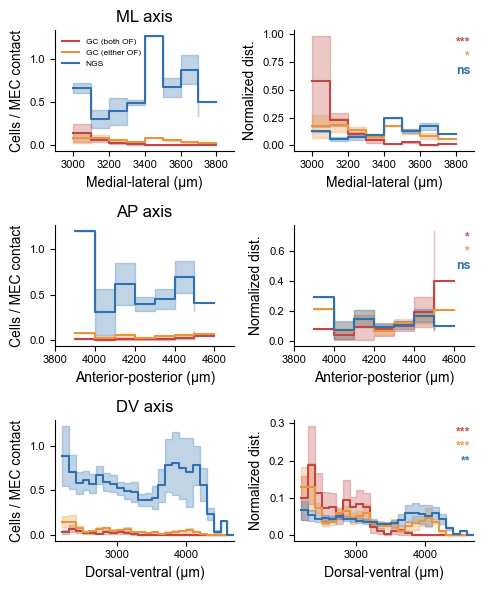

In [43]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial'

def mean_sem(arr):
    mean = np.nanmean(arr, axis=0)
    sem = np.nanstd(arr, axis=0) / np.sqrt(np.sum(~np.isnan(arr), axis=0))
    return mean, sem

def plot_step_with_sem(ax, bins, mean, sem, color, label=None, div2=False):
    y = mean / 2 if div2 else mean
    yerr = sem / 2 if div2 else sem
    ax.step(bins[:-1], y, where='post', color=color, label=label)
    ax.fill_between(bins[:-1], y - yerr, y + yerr, step='post', color=color, alpha=0.3)

def pval_to_stars(p):
    if p is None or np.isnan(p):
        return 'n.s.'
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'

def get_occupied_xlim(hists, bins):
    all_occupied = np.zeros(len(bins) - 1, dtype=bool)
    for name, hist in hists.items():
        m = np.nanmean(hist, axis=0)
        all_occupied |= (m > 0) & ~np.isnan(m)
    occupied_idx = np.where(all_occupied)[0]
    if len(occupied_idx) == 0:
        return (bins[0], bins[-1])
    return (bins[occupied_idx[0]] - 100, bins[occupied_idx[-1] + 1] + 100)

COL_BOTH   = '#c04744'
COL_EITHER = '#e8963e'
COL_NGS    = '#3171ae'

group_style = [
    ('GC_both',   COL_BOTH,   'GC (both OF)'),
    ('GC_either', COL_EITHER, 'GC (either OF)'),
    ('NGS',       COL_NGS,    'NGS'),
]

fig, axes = plt.subplots(3, 2, figsize=(5, 6))

for row, (hists, bins, pvals, axis_name, xlabel) in enumerate([
    (hists_ml, ml_bins, pvals_ml, 'ML', 'Medial-lateral (µm)'),
    (hists_ap, ap_bins, pvals_ap, 'AP', 'Anterior-posterior (µm)'),
    (hists_dv, dv_bins, pvals_dv, 'DV', 'Dorsal-ventral (µm)'),
]):
    xlim = get_occupied_xlim(hists, bins)

    # Left: cells per MEC contact
    for name, color, label in group_style:
        m, s = mean_sem(hists[name])
        plot_step_with_sem(axes[row, 0], bins, m, s, color, label=label, div2=True)
    axes[row, 0].set_xlabel(xlabel)
    axes[row, 0].set_ylabel('Cells / MEC contact')
    axes[row, 0].set_title(f'{axis_name} axis', fontsize=12, fontweight='normal')
    axes[row, 0].set_xlim(xlim)
    if row == 0:
        axes[row, 0].legend(fontsize=6, frameon=False)

    # Right: normalized distribution with uniformity stars
    for name, color, label in group_style:
        m, s = mean_sem(hists[name])
        total = np.nansum(m)
        if total > 0:
            plot_step_with_sem(axes[row, 1], bins, m / total, s / total, color)
    axes[row, 1].set_xlabel(xlabel)
    axes[row, 1].set_ylabel('Normalized dist.')
    axes[row, 1].set_xlim(xlim)

    # Annotate stars in each group's color
    for i, (name, color, label) in enumerate(group_style):
        p = pvals.get(name, np.nan)
        stars = pval_to_stars(p)
        axes[row, 1].annotate(stars,
                              xy=(0.98, 0.95 - i * 0.12), xycoords='axes fraction',
                              ha='right', va='top', fontsize=9, fontweight='bold',
                              color=color)

for ax_row in axes:
    for ax in ax_row:
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/cells_per_contact_per_axis_gc_split.pdf', bbox_inches='tight', dpi=300)
plt.show()


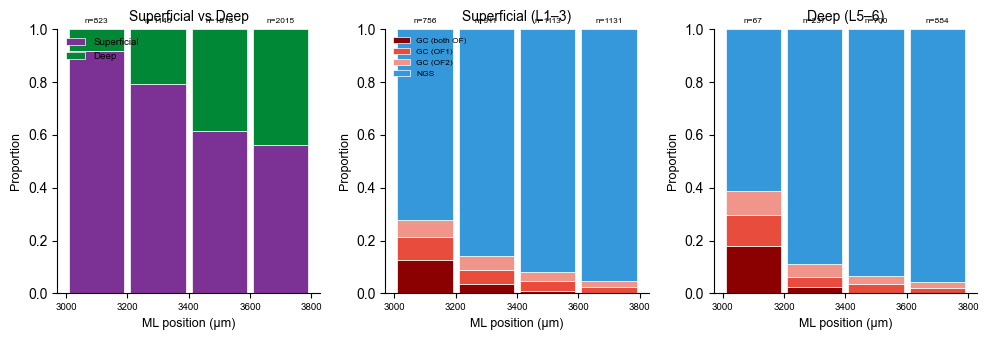

In [29]:
import matplotlib.pyplot as plt
import numpy as np

ml_all = -_df['SC_x']

cats = []
for _, row in _df.iterrows():
    if row['cell_type'] == 'GC':
        cb = row.get('classified_by', 'OF1')
        cats.append(cb if cb in ('both', 'OF1', 'OF2') else 'OF1')
    elif row['cell_type'] == 'NG':
        cats.append('NGS')
    else:
        cats.append(None)
_df['_cat'] = cats

def get_layer(region):
    if not isinstance(region, str):
        return None
    r = region.upper()
    if any(x in r for x in ['ENTM1', 'ENTM2', 'ENTM3']):
        return 'Superficial'
    elif any(x in r for x in ['ENTM5', 'ENTM6']):
        return 'Deep'
    return None

col = 'brain_region' if 'brain_region' in _df.columns else 'annotation'
_df['_layer'] = _df[col].apply(get_layer)

keep = (_df['_cat'].notna() & _df['_layer'].notna() &
        ml_all.notna() & _df['cell_type'].isin(['GC', 'NG']))
df_all = _df[keep].copy()
df_all['_ml'] = ml_all[keep]

bin_edges = np.arange(3000, 3801, 200)
bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2

cat_order = ['both', 'OF1', 'OF2', 'NGS']
cat_colors = {'both': '#8B0000', 'OF1': '#e74c3c', 'OF2': '#f1948a', 'NGS': '#3498db'}
cat_labels = {'both': 'GC (both OF)', 'OF1': 'GC (OF1)', 'OF2': 'GC (OF2)', 'NGS': 'NGS'}

layer_order = ['Superficial', 'Deep']
layer_colors = {'Superficial': '#7b3294', 'Deep': '#008837'}

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))

# ── Panel 0: Superficial vs Deep proportions by ML ───────────────────────────
ax = axes[0]
df_all['_bin'] = pd.cut(df_all['_ml'], bins=bin_edges, right=False)

counts_layer = df_all.groupby(['_bin', '_layer']).size().unstack(fill_value=0)
for c in layer_order:
    if c not in counts_layer.columns:
        counts_layer[c] = 0
counts_layer = counts_layer[layer_order]
props_layer = counts_layer.div(counts_layer.sum(axis=1), axis=0)

bottom = np.zeros(len(props_layer))
for layer in layer_order:
    vals = props_layer[layer].values
    ax.bar(bin_centres, vals, width=180, bottom=bottom,
           color=layer_colors[layer], label=layer,
           edgecolor='white', lw=0.5)
    bottom += vals

ax.set_xlabel('ML position (µm)', fontsize=9)
ax.set_ylabel('Proportion', fontsize=9)
ax.set_title('Superficial vs Deep', fontsize=10)
ax.set_xticks(bin_edges)
ax.set_xticklabels([f'{int(e)}' for e in bin_edges], fontsize=7)
ax.set_ylim(0, 1)
ax.legend(fontsize=7, loc='upper left', frameon=False)
ax.spines[['top', 'right']].set_visible(False)

for j, (centre, total) in enumerate(zip(bin_centres, counts_layer.sum(axis=1).values)):
    ax.text(centre, 1.02, f'n={int(total)}', ha='center', va='bottom', fontsize=6)

# ── Panel 1: Superficial — cell type proportions by ML ───────────────────────
# ── Panel 2: Deep — cell type proportions by ML ──────────────────────────────
for i, layer in enumerate(layer_order):
    ax = axes[i + 1]
    df_layer = df_all[df_all['_layer'] == layer].copy()
    df_layer['_bin'] = pd.cut(df_layer['_ml'], bins=bin_edges, right=False)

    counts = df_layer.groupby(['_bin', '_cat']).size().unstack(fill_value=0)
    for c in cat_order:
        if c not in counts.columns:
            counts[c] = 0
    counts = counts[cat_order]
    proportions = counts.div(counts.sum(axis=1), axis=0)

    bottom = np.zeros(len(proportions))
    for cat in cat_order:
        vals = proportions[cat].values
        ax.bar(bin_centres, vals, width=180, bottom=bottom,
               color=cat_colors[cat], label=cat_labels[cat],
               edgecolor='white', lw=0.5)
        bottom += vals

    ax.set_xlabel('ML position (µm)', fontsize=9)
    ax.set_ylabel('Proportion', fontsize=9)
    ax.set_title(f'{layer} (L1–3)' if layer == 'Superficial' else f'{layer} (L5–6)',
                 fontsize=10)
    ax.set_xticks(bin_edges)
    ax.set_xticklabels([f'{int(e)}' for e in bin_edges], fontsize=7)
    ax.set_ylim(0, 1)
    ax.spines[['top', 'right']].set_visible(False)

    for j, (centre, total) in enumerate(zip(bin_centres, counts.sum(axis=1).values)):
        ax.text(centre, 1.02, f'n={int(total)}', ha='center', va='bottom', fontsize=6)

    if i == 0:
        ax.legend(fontsize=6, loc='upper left', frameon=False)

plt.tight_layout()
plt.show()

_df.drop(columns=['_cat', '_layer'], inplace=True)


In [11]:
device_contacts = pd.read_csv('/Users/harryclark/Downloads/device_contact_id_annotations.csv')
device_contacts['coord_SCs_x'] = np.abs(device_contacts['coord_SCs_x'])

3000–3200 µm: 4 both + 4 single = 8
  M28D25 c153  ML=3120  both  GS_OF1=1.27  GS_OF2=1.49
  M28D21 c82  ML=3120  both  GS_OF1=0.86  GS_OF2=1.44
  M25D24 c152  ML=3000  both  GS_OF1=1.44  GS_OF2=1.38
  M21D21 c203  ML=3195  both  GS_OF1=1.18  GS_OF2=1.39
  M21D21 c281  ML=3197  OF1  GS_OF1=1.30  GS_OF2=-0.24
  M25D21 c116  ML=3000  OF1  GS_OF1=1.13  GS_OF2=-0.39
  M21D26 c169  ML=3197  OF2  GS_OF1=-0.00  GS_OF2=1.12
  M26D19 c123  ML=3180  OF1  GS_OF1=1.09  GS_OF2=0.43
3200–3400 µm: 4 both + 4 single = 8
  M28D19 c128  ML=3360  both  GS_OF1=1.29  GS_OF2=1.34
  M29D25 c368  ML=3270  both  GS_OF1=1.31  GS_OF2=0.90
  M29D23 c184  ML=3270  both  GS_OF1=1.26  GS_OF2=0.84
  M27D23 c263  ML=3210  both  GS_OF1=0.88  GS_OF2=1.22
  M25D25 c88  ML=3270  OF2  GS_OF1=0.31  GS_OF2=1.21
  M28D17 c134  ML=3360  OF2  GS_OF1=-0.10  GS_OF2=1.13
  M21D21 c381  ML=3201  OF1  GS_OF1=1.03  GS_OF2=-0.08
  M28D23 c194  ML=3360  OF2  GS_OF1=0.11  GS_OF2=0.99
3400–3600 µm: 4 both + 4 single = 8
  M29D20 c53  ML=

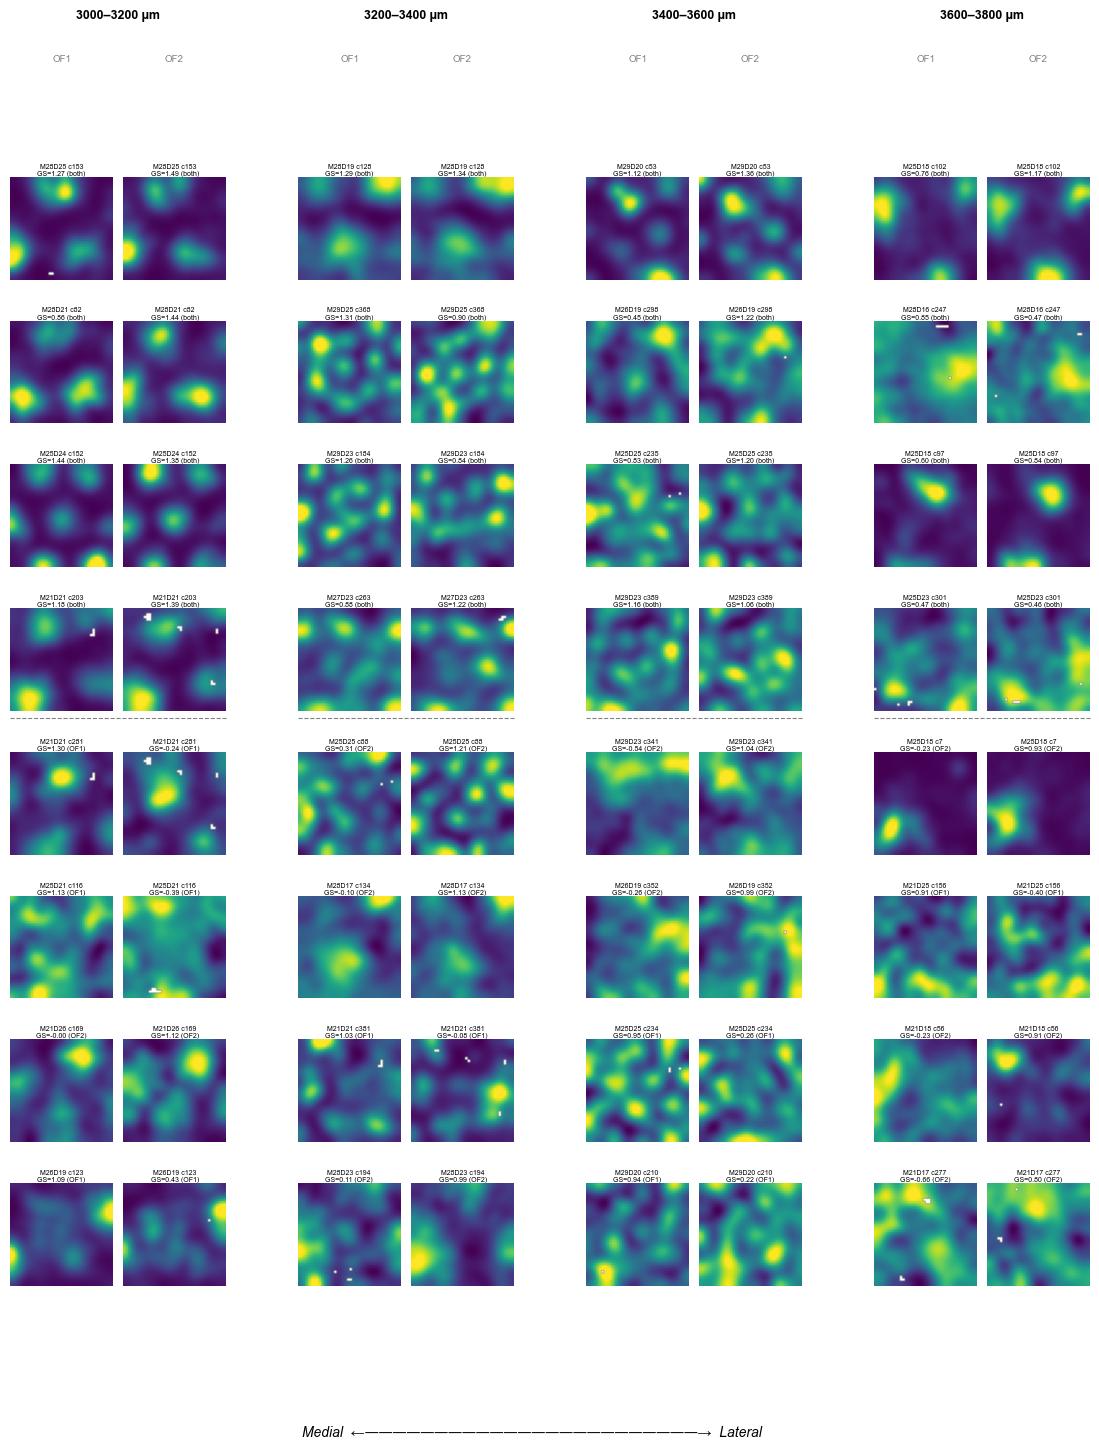

In [38]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import pynapple as nap
from spatial_manifolds.detect_grids import compute_travel_projected, gaussian_filter_nan,_fill_nans_from_neighbors

SOURCE_PATH = '/Users/harryclark/Downloads/COHORT12/'

def plot_of_rate_map(ax, cluster_id, mouse, day, df, session='OF1', source_path=SOURCE_PATH):
    folder = f'{source_path}M{int(mouse)}/D{int(day):02}/{session}/'
    spikes_path = folder + f"sub-{int(mouse)}_day-{int(day):02}_ses-{session}_srt-kilosort4_clusters.npz"
    beh_path = folder + f"sub-{int(mouse)}_day-{int(day):02}_ses-{session}_beh.nwb"

    beh = nap.load_file(beh_path)
    clusters = nap.load_file(spikes_path)

    optimal_lag = df[df.cluster_id == cluster_id].travel.values[0]
    position = np.stack([beh['P_x'], beh['P_y']], axis=1)
    beh_lag = compute_travel_projected(["P_x", "P_y"], position, position, optimal_lag)
    position_lagged = np.stack([beh_lag['P_x'], beh_lag['P_y']], axis=1)

    tc = nap.compute_2d_tuning_curves(nap.TsGroup([clusters[cluster_id]]), position_lagged, nb_bins=(40, 40))[0][0]
    tc = _fill_nans_from_neighbors(tc)
    tc = gaussian_filter_nan(tc, sigma=(2.5, 2.5))
    tc = np.clip(tc, a_min=0, a_max=np.nanpercentile(tc, 99))

    ax.imshow(tc, cmap='viridis')
    ax.axis('off')

_df = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')
gc = _df[_df['cell_type'] == 'GC'].copy()
gc['ml'] = gc['SC_x'].abs()

gc_both = gc[(gc['classified_by'] == 'both') &
             gc['grid_score_of1'].notna() &
             gc['grid_score_of2'].notna()].copy()

gc_single = gc[(gc['classified_by'].isin(['OF1', 'OF2'])) &
               gc['grid_score_of1'].notna() &
               gc['grid_score_of2'].notna()].copy()

N_BOTH = 4
N_SINGLE = 4
N_PER_BIN = N_BOTH + N_SINGLE
bin_edges = np.arange(3000, 3801, 200)
bin_labels = [f'{bin_edges[i]}–{bin_edges[i+1]} µm' for i in range(len(bin_edges) - 1)]
n_bins = len(bin_edges) - 1

examples = {}
for i in range(n_bins):
    lo, hi = bin_edges[i], bin_edges[i + 1]

    both_sub = gc_both[(gc_both['ml'] >= lo) & (gc_both['ml'] < hi)]
    both_top = both_sub.sort_values('grid_score_best', ascending=False).head(N_BOTH)

    single_sub = gc_single[(gc_single['ml'] >= lo) & (gc_single['ml'] < hi)]
    single_top = single_sub.sort_values('grid_score_best', ascending=False).head(N_SINGLE)

    combined = pd.concat([both_top, single_top])
    examples[i] = combined
    print(f"{bin_labels[i]}: {len(both_top)} both + {len(single_top)} single = {len(combined)}")
    for _, ex in combined.iterrows():
        print(f"  M{int(ex.mouse)}D{int(ex.day)} c{int(ex.cluster_id)}  "
              f"ML={ex.ml:.0f}  {ex.classified_by}  "
              f"GS_OF1={ex.grid_score_of1:.2f}  GS_OF2={ex.grid_score_of2:.2f}")

# ── Layout ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(n_bins * 3.5, N_PER_BIN * 1.8))
outer = gridspec.GridSpec(1, n_bins, figure=fig, wspace=0.3)

for b in range(n_bins):
    inner = outer[b].subgridspec(N_PER_BIN, 2, wspace=0.05, hspace=0.4)
    cells = examples[b]

    mid_x = (outer[b].get_position(fig).x0 + outer[b].get_position(fig).x1) / 2
    fig.text(mid_x, 0.99, bin_labels[b], ha='center', fontsize=9, weight='bold')
    fig.text(mid_x - 0.04, 0.96, 'OF1', ha='center', fontsize=7, color='grey')
    fig.text(mid_x + 0.04, 0.96, 'OF2', ha='center', fontsize=7, color='grey')

    for row in range(N_PER_BIN):
        ax_of1 = fig.add_subplot(inner[row, 0])
        ax_of2 = fig.add_subplot(inner[row, 1])

        if row < len(cells):
            ex = cells.iloc[row]
            mouse, day, cid = int(ex.mouse), int(ex.day), int(ex.cluster_id)
            cb = ex.classified_by

            for ax, session in [(ax_of1, 'OF1'), (ax_of2, 'OF2')]:
                try:
                    plot_of_rate_map(ax, cid, mouse, day, _df, session=session)
                except Exception as e:
                    ax.text(0.5, 0.5, '—', ha='center', va='center',
                            transform=ax.transAxes, fontsize=10, color='grey')
                    ax.axis('off')
                    print(f"  Failed M{mouse}D{day} c{cid} {session}: {e}")

                gs = ex[f'grid_score_{session.lower()}']
                ax.set_title(f'M{mouse}D{day} c{cid}\nGS={gs:.2f} ({cb})', fontsize=5, pad=1)

            # Divider line between "both" and "single" groups
            if row == N_BOTH - 1 and row < len(cells) - 1:
                ax_of1_pos = ax_of1.get_position()
                ax_of2_pos = ax_of2.get_position()
                y_line = ax_of1_pos.y0 - 0.005
                fig.add_artist(plt.Line2D(
                    [ax_of1_pos.x0, ax_of2_pos.x1], [y_line, y_line],
                    transform=fig.transFigure, color='grey', lw=0.8, ls='--'))
        else:
            ax_of1.axis('off')
            ax_of2.axis('off')

fig.text(0.5, 0.005, 'Medial  ←――――――――――――――――――――――――→  Lateral',
         ha='center', fontsize=10, style='italic')

plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/gc_rate_maps_ml_bins_broad.pdf',
            bbox_inches='tight', dpi=300)
plt.show()


In [ ]:
_df

,Unnamed: 0,cluster_id,brain_region,grid_score,field_size,field_spacing,orientation,_smooth_sigma,travel,sig,...,classified_by,cell_type,grid_module,ramp_cell,speed_modulated,vr_outbound_sign,vr_homebound_sign,vr_spatial_information,vr_spatial_information_sig,shank_id
0,0,34,ENTm1,-0.370568,40.728949,54.305265,28.178439,1.5,2,False,...,OF2,GC,NaN,False,False,NaN,NaN,0.210157,True,0.0
1,1,103,ENTm1,-0.140560,58.812343,78.416458,15.687386,1.5,2,False,...,OF2,GC,NaN,True,True,-,+,0.075680,True,1.0
2,2,400,ENTm3,-0.186061,36.455207,48.606943,15.708574,1.5,2,False,...,OF2,GC,NaN,False,False,NaN,NaN,0.000109,False,3.0
3,3,412,ENTm5,0.440898,22.391733,29.855644,25.110225,1.5,2,True,...,OF1,GC,NaN,False,False,NaN,NaN,0.005485,True,3.0
4,0,37,ENTm1,-0.716572,26.094122,34.792162,10.002436,1.5,2,False,...,both,NG,NaN,True,False,-,+,0.091285,True,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8911,197,550,ENTm5,-0.111145,18.568656,24.758209,4.706601,1.5,7,False,...,NaN,Other,NaN,False,False,NaN,NaN,0.064190,True,3.0
8912,198,552,ENTm5,-0.255859,37.339592,49.786123,5.587589,1.5,7,False,...,NaN,Other,NaN,False,False,NaN,NaN,0.038080,True,3.0
8913,199,553,ENTm5,0.745899,50.170017,66.893356,55.679758,1.5,7,True,...,NaN,Other,NaN,False,False,NaN,NaN,0.049365,True,3.0
8914,200,554,ENTm5,-0.193868,33.850811,45.134414,28.797167,1.5,7,False,...,NaN,Other,NaN,False,False,NaN,NaN,0.022946,True,3.0


: 

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Only consider cells in ENT region
def get_ent_mask(df):
    ap_idx = np.round((df['coord_SCs_z'] - ap_axis[0]) / (ap_axis[1] - ap_axis[0])).astype(int)
    dv_idx = np.round((df['coord_SCs_y'] - dv_axis[0]) / (dv_axis[1] - dv_axis[0])).astype(int)
    ml_idx = np.round((-df['coord_SCs_x'] - ml_axis[0]) / (ml_axis[1] - ml_axis[0])).astype(int)
    mask = []
    for a, d, m in zip(ap_idx, dv_idx, ml_idx):
        if (0 <= a < len(ap_axis)) and (0 <= d < len(dv_axis)) and (0 <= m < len(ml_axis)):
            mask.append(annotation_colors[a, d, m] == 'silver')
        else:
            mask.append(False)
    return np.array(mask)

gcs_ent = gcs_[get_ent_mask(gcs_)]
ngs_ent = ngs_[get_ent_mask(ngs_)]

# Bin size (100 µm)
ml_bins = np.arange(ml_axis.min(), ml_axis.max() + 100, 100)
ap_bins = np.arange(ap_axis.min(), ap_axis.max() + 100, 100)
dv_bins = np.arange(dv_axis.min(), dv_axis.max() + 100, 100)

# Device contacts
ml_contacts = device_contacts['coord_SCs_x'] * -1
ap_contacts = device_contacts['coord_SCs_z']
dv_contacts = device_contacts['coord_SCs_y']

# Only consider device contacts in ENT region
def get_ent_contact_mask(df):
    ap_idx = np.round((df['coord_SCs_z'] - ap_axis[0]) / (ap_axis[1] - ap_axis[0])).astype(int)
    dv_idx = np.round((df['coord_SCs_y'] - dv_axis[0]) / (dv_axis[1] - dv_axis[0])).astype(int)
    ml_idx = np.round((-df['coord_SCs_x'] - ml_axis[0]) / (ml_axis[1] - ml_axis[0])).astype(int)
    mask = []
    for a, d, m in zip(ap_idx, dv_idx, ml_idx):
        if (0 <= a < len(ap_axis)) and (0 <= d < len(dv_axis)) and (0 <= m < len(ml_axis)):
            mask.append(annotation_colors[a, d, m] == 'silver')
        else:
            mask.append(False)
    return np.array(mask)

ent_contact_mask = get_ent_contact_mask(device_contacts)
ent_contacts = device_contacts[ent_contact_mask]
ml_contacts_ent = ml_contacts[ent_contact_mask]
ap_contacts_ent = ap_contacts[ent_contact_mask]
dv_contacts_ent = dv_contacts[ent_contact_mask]

# Grid cells (ENT only)
ml_gcs_ent = gcs_ent['coord_SCs_x'] * -1
ap_gcs_ent = gcs_ent['coord_SCs_z']
dv_gcs_ent = gcs_ent['coord_SCs_y']

# Non-grid cells (ENT only)
ml_ngs_ent = ngs_ent['coord_SCs_x'] * -1
ap_ngs_ent = ngs_ent['coord_SCs_z']
dv_ngs_ent = ngs_ent['coord_SCs_y']

# Helper for safe division
def safe_divide(a, b):
    out = np.zeros_like(a, dtype=float)
    mask = b > 0
    out[mask] = a[mask] / b[mask]
    out[~mask] = np.nan
    return out

# ML axis
contacts_ml, _ = np.histogram(ml_contacts_ent, bins=ml_bins)
gcs_ml, _ = np.histogram(ml_gcs_ent, bins=ml_bins)
ngs_ml, _ = np.histogram(ml_ngs_ent, bins=ml_bins)
gcs_per_contact_ml = safe_divide(gcs_ml, contacts_ml)
ngs_per_contact_ml = safe_divide(ngs_ml, contacts_ml)

# AP axis
contacts_ap, _ = np.histogram(ap_contacts_ent, bins=ap_bins)
gcs_ap, _ = np.histogram(ap_gcs_ent, bins=ap_bins)
ngs_ap, _ = np.histogram(ap_ngs_ent, bins=ap_bins)
gcs_per_contact_ap = safe_divide(gcs_ap, contacts_ap)
ngs_per_contact_ap = safe_divide(ngs_ap, contacts_ap)

# DV axis
contacts_dv, _ = np.histogram(dv_contacts_ent, bins=dv_bins)
gcs_dv, _ = np.histogram(dv_gcs_ent, bins=dv_bins)
ngs_dv, _ = np.histogram(dv_ngs_ent, bins=dv_bins)
gcs_per_contact_dv = safe_divide(gcs_dv, contacts_dv)
ngs_per_contact_dv = safe_divide(ngs_dv, contacts_dv)

# Cumulative density for each axis
def cumulative_density(hist):
    cumsum = np.nancumsum(hist)
    if np.nansum(hist) > 0:
        return cumsum / np.nansum(hist)
    else:
        return np.full_like(hist, np.nan, dtype=float)

gcs_cum_ml = cumulative_density(gcs_ml)
ngs_cum_ml = cumulative_density(ngs_ml)
gcs_cum_ap = cumulative_density(gcs_ap)
ngs_cum_ap = cumulative_density(ngs_ap)
gcs_cum_dv = cumulative_density(gcs_dv)
ngs_cum_dv = cumulative_density(ngs_dv)


IndexError: index 403 is out of bounds for axis 1 with size 400

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
n_mice = len(mouse_ids)

# --- ML axis ---
n_bins_ml = len(ml_bins) - 1
gcs_cells_per_entcontact_ml = np.full((n_bins_ml, n_mice), np.nan)
ngs_cells_per_entcontact_ml = np.full((n_bins_ml, n_mice), np.nan)

for i_mouse, mouse in enumerate(mouse_ids):
    gcs_mouse = gcs_ent[gcs_ent['mouse'] == mouse]
    contacts_mouse = ent_contacts[ent_contacts['mouse'] == mouse]
    gcs_counts, _ = np.histogram(gcs_mouse['coord_SCs_x'] * -1, bins=ml_bins)
    contact_counts, _ = np.histogram(contacts_mouse['coord_SCs_x'] * -1, bins=ml_bins)
    with np.errstate(divide='ignore', invalid='ignore'):
        per_contact = gcs_counts / contact_counts
    gcs_cells_per_entcontact_ml[:, i_mouse] = per_contact

for i_mouse, mouse in enumerate(mouse_ids):
    ngs_mouse = ngs_ent[ngs_ent['mouse'] == mouse]
    contacts_mouse = ent_contacts[ent_contacts['mouse'] == mouse]
    ngs_counts, _ = np.histogram(ngs_mouse['coord_SCs_x'] * -1, bins=ml_bins)
    contact_counts, _ = np.histogram(contacts_mouse['coord_SCs_x'] * -1, bins=ml_bins)
    with np.errstate(divide='ignore', invalid='ignore'):
        per_contact = ngs_counts / contact_counts
    ngs_cells_per_entcontact_ml[:, i_mouse] = per_contact

data_ml = []
for i_mouse, mouse in enumerate(mouse_ids):
    for i_bin in range(n_bins_ml):
        data_ml.append({
            'value': gcs_cells_per_entcontact_ml[i_bin, i_mouse],
            'group': 'GCS',
            'bin': ml_bins[i_bin],
            'mouse': mouse
        })
        data_ml.append({
            'value': ngs_cells_per_entcontact_ml[i_bin, i_mouse],
            'group': 'NGS',
            'bin': ml_bins[i_bin],
            'mouse': mouse
        })
df_ml = pd.DataFrame(data_ml).dropna(subset=['value'])
model_ml = smf.mixedlm("value ~ group * bin", df_ml, groups=df_ml["mouse"])
result_ml = model_ml.fit(method="powell", maxiter=5000)
print("ML axis GLMM:")
print(result_ml.summary())

# --- AP axis ---
n_bins_ap = len(ap_bins) - 1
gcs_cells_per_entcontact_ap = np.full((n_bins_ap, n_mice), np.nan)
ngs_cells_per_entcontact_ap = np.full((n_bins_ap, n_mice), np.nan)

for i_mouse, mouse in enumerate(mouse_ids):
    gcs_mouse = gcs_ent[gcs_ent['mouse'] == mouse]
    contacts_mouse = ent_contacts[ent_contacts['mouse'] == mouse]
    gcs_counts, _ = np.histogram(gcs_mouse['coord_SCs_z'], bins=ap_bins)
    contact_counts, _ = np.histogram(contacts_mouse['coord_SCs_z'], bins=ap_bins)
    with np.errstate(divide='ignore', invalid='ignore'):
        per_contact = gcs_counts / contact_counts
    gcs_cells_per_entcontact_ap[:, i_mouse] = per_contact

for i_mouse, mouse in enumerate(mouse_ids):
    ngs_mouse = ngs_ent[ngs_ent['mouse'] == mouse]
    contacts_mouse = ent_contacts[ent_contacts['mouse'] == mouse]
    ngs_counts, _ = np.histogram(ngs_mouse['coord_SCs_z'], bins=ap_bins)
    contact_counts, _ = np.histogram(contacts_mouse['coord_SCs_z'], bins=ap_bins)
    with np.errstate(divide='ignore', invalid='ignore'):
        per_contact = ngs_counts / contact_counts
    ngs_cells_per_entcontact_ap[:, i_mouse] = per_contact

data_ap = []
for i_mouse, mouse in enumerate(mouse_ids):
    for i_bin in range(n_bins_ap):
        data_ap.append({
            'value': gcs_cells_per_entcontact_ap[i_bin, i_mouse],
            'group': 'GCS',
            'bin': ap_bins[i_bin],
            'mouse': mouse
        })
        data_ap.append({
            'value': ngs_cells_per_entcontact_ap[i_bin, i_mouse],
            'group': 'NGS',
            'bin': ap_bins[i_bin],
            'mouse': mouse
        })
df_ap = pd.DataFrame(data_ap).dropna(subset=['value'])
model_ap = smf.mixedlm("value ~ group * bin", df_ap, groups=df_ap["mouse"])
result_ap = model_ap.fit(method="powell", maxiter=5000)
print("AP axis GLMM:")
print(result_ap.summary())

# --- DV axis ---
n_bins_dv = len(dv_bins) - 1
gcs_cells_per_entcontact_dv = np.full((n_bins_dv, n_mice), np.nan)
ngs_cells_per_entcontact_dv = np.full((n_bins_dv, n_mice), np.nan)

for i_mouse, mouse in enumerate(mouse_ids):
    gcs_mouse = gcs_ent[gcs_ent['mouse'] == mouse]
    contacts_mouse = ent_contacts[ent_contacts['mouse'] == mouse]
    gcs_counts, _ = np.histogram(gcs_mouse['coord_SCs_y'], bins=dv_bins)
    contact_counts, _ = np.histogram(contacts_mouse['coord_SCs_y'], bins=dv_bins)
    with np.errstate(divide='ignore', invalid='ignore'):
        per_contact = gcs_counts / contact_counts
    gcs_cells_per_entcontact_dv[:, i_mouse] = per_contact

for i_mouse, mouse in enumerate(mouse_ids):
    ngs_mouse = ngs_ent[ngs_ent['mouse'] == mouse]
    contacts_mouse = ent_contacts[ent_contacts['mouse'] == mouse]
    ngs_counts, _ = np.histogram(ngs_mouse['coord_SCs_y'], bins=dv_bins)
    contact_counts, _ = np.histogram(contacts_mouse['coord_SCs_y'], bins=dv_bins)
    with np.errstate(divide='ignore', invalid='ignore'):
        per_contact = ngs_counts / contact_counts
    ngs_cells_per_entcontact_dv[:, i_mouse] = per_contact

data_dv = []
for i_mouse, mouse in enumerate(mouse_ids):
    for i_bin in range(n_bins_dv):
        data_dv.append({
            'value': gcs_cells_per_entcontact_dv[i_bin, i_mouse],
            'group': 'GCS',
            'bin': dv_bins[i_bin],
            'mouse': mouse
        })
        data_dv.append({
            'value': ngs_cells_per_entcontact_dv[i_bin, i_mouse],
            'group': 'NGS',
            'bin': dv_bins[i_bin],
            'mouse': mouse
        })
df_dv = pd.DataFrame(data_dv).dropna(subset=['value'])
model_dv = smf.mixedlm("value ~ group * bin", df_dv, groups=df_dv["mouse"])
result_dv = model_dv.fit(method="powell", maxiter=5000)
print("DV axis GLMM:")
print(result_dv.summary())

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(5, 6))  # smaller size

# Divide by 2 to correct for double counting, and rename variables
gcs_per_contact_ml_div2 = gcs_per_contact_ml / 2
ngs_per_contact_ml_div2 = ngs_per_contact_ml / 2
gcs_per_contact_ap_div2 = gcs_per_contact_ap / 2
ngs_per_contact_ap_div2 = ngs_per_contact_ap / 2
gcs_per_contact_dv_div2 = gcs_per_contact_dv / 2
ngs_per_contact_dv_div2 = ngs_per_contact_dv / 2

# ML axis
axes[0, 0].step(ml_bins[:-1], gcs_per_contact_ml_div2, where='post', color='#c04744')
axes[0, 0].step(ml_bins[:-1], ngs_per_contact_ml_div2, where='post', color='#3171ae')
axes[0, 0].set_xlabel('Medial-lateral (µm)')
axes[0, 0].set_ylabel('Cells / MEC contact')
axes[0, 0].set_title('ML axis', fontsize=12, fontweight='normal')

gcs_density_ml = gcs_per_contact_ml_div2 / np.nansum(gcs_per_contact_ml_div2)
ngs_density_ml = ngs_per_contact_ml_div2 / np.nansum(ngs_per_contact_ml_div2)
axes[0, 1].step(ml_bins[:-1], gcs_density_ml, where='post', color='#c04744')
axes[0, 1].step(ml_bins[:-1], ngs_density_ml, where='post', color='#3171ae')
axes[0, 1].set_xlabel('Medial-lateral (µm)')
axes[0, 1].set_ylabel('Density')


# Annotate with LMM p-value for ML
axes[0, 1].annotate(
    f"p = {result_ml.pvalues['group[T.NGS]:bin']:.2g}",
    xy=(0.98, 0.15), xycoords='axes fraction',
    ha='right', va='top', fontsize=10
)

# Set same x limits for ML row
ml_xlim = (2800, 3900)
axes[0, 0].set_xlim(ml_xlim)
axes[0, 1].set_xlim(ml_xlim)

# AP axis
axes[1, 0].step(ap_bins[:-1], gcs_per_contact_ap_div2, where='post', color='#c04744')
axes[1, 0].step(ap_bins[:-1], ngs_per_contact_ap_div2, where='post', color='#3171ae')
axes[1, 0].set_xlabel('Anterior-posterior (µm)')
axes[1, 0].set_ylabel('Cells / MEC contact')
axes[1, 0].set_title('AP axis', fontsize=12, fontweight='normal')

gcs_density_ap = gcs_per_contact_ap_div2 / np.nansum(gcs_per_contact_ap_div2)
ngs_density_ap = ngs_per_contact_ap_div2 / np.nansum(ngs_per_contact_ap_div2)
axes[1, 1].step(ap_bins[:-1], gcs_density_ap, where='post', color='#c04744')
axes[1, 1].step(ap_bins[:-1], ngs_density_ap, where='post', color='#3171ae')
axes[1, 1].set_xlabel('Anterior-posterior (µm)')
axes[1, 1].set_ylabel('Density')

# Annotate with LMM p-value for AP
axes[1, 1].annotate(
    f"p = {result_ap.pvalues['group[T.NGS]:bin']:.2g}",
    xy=(0.02, 0.05), xycoords='axes fraction',
    ha='left', va='bottom', fontsize=10
)

# Set same x limits for AP row
ap_xlim = (3800, 4700)
axes[1, 0].set_xlim(ap_xlim)
axes[1, 1].set_xlim(ap_xlim)

# DV axis
axes[2, 0].step(dv_bins[:-1], gcs_per_contact_dv_div2, where='post', color='#c04744')
axes[2, 0].step(dv_bins[:-1], ngs_per_contact_dv_div2, where='post', color='#3171ae')
axes[2, 0].set_xlabel('Dorsal-ventral (µm)')
axes[2, 0].set_ylabel('Cells / MEC contact')
axes[2, 0].set_title('DV axis', fontsize=12, fontweight='normal')

gcs_density_dv = gcs_per_contact_dv_div2 / np.nansum(gcs_per_contact_dv_div2)
ngs_density_dv = ngs_per_contact_dv_div2 / np.nansum(ngs_per_contact_dv_div2)
axes[2, 1].step(dv_bins[:-1], gcs_density_dv, where='post', color='#c04744')
axes[2, 1].step(dv_bins[:-1], ngs_density_dv, where='post', color='#3171ae')
axes[2, 1].set_xlabel('Dorsal-ventral (µm)')
axes[2, 1].set_ylabel('Density')

# Annotate with LMM p-value for DV
axes[2, 1].annotate(
    f"p = {result_dv.pvalues['group[T.NGS]:bin']:.2g}",
    xy=(0.02, 0.05), xycoords='axes fraction',
    ha='left', va='bottom', fontsize=10
)

# Set same x limits for DV row
dv_xlim = (2000, 4800)
axes[2, 0].set_xlim(dv_xlim)
axes[2, 1].set_xlim(dv_xlim)

plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/cells_per_contact_per_axis_ENTonly_cumulative.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Compute per-mouse histograms for each axis and cell type ---
n_mice = len(mouse_ids)
n_bins_ml = len(ml_bins) - 1
n_bins_ap = len(ap_bins) - 1
n_bins_dv = len(dv_bins) - 1

gcs_hist_ml = np.full((n_mice, n_bins_ml), np.nan)
ngs_hist_ml = np.full((n_mice, n_bins_ml), np.nan)
gcs_hist_ap = np.full((n_mice, n_bins_ap), np.nan)
ngs_hist_ap = np.full((n_mice, n_bins_ap), np.nan)
gcs_hist_dv = np.full((n_mice, n_bins_dv), np.nan)
ngs_hist_dv = np.full((n_mice, n_bins_dv), np.nan)

for i_mouse, mouse in enumerate(mouse_ids):
    gcs_mouse = gcs_ent[gcs_ent['mouse'] == mouse]
    ngs_mouse = ngs_ent[ngs_ent['mouse'] == mouse]
    contacts_mouse = ent_contacts[ent_contacts['mouse'] == mouse]

    # ML axis
    contacts_ml, _ = np.histogram(contacts_mouse['coord_SCs_x'] * -1, bins=ml_bins)
    gcs_ml, _ = np.histogram(gcs_mouse['coord_SCs_x'] * -1, bins=ml_bins)
    ngs_ml, _ = np.histogram(ngs_mouse['coord_SCs_x'] * -1, bins=ml_bins)
    gcs_hist_ml[i_mouse] = np.divide(gcs_ml, contacts_ml, out=np.full_like(gcs_ml, np.nan, dtype=float), where=contacts_ml > 0)
    ngs_hist_ml[i_mouse] = np.divide(ngs_ml, contacts_ml, out=np.full_like(ngs_ml, np.nan, dtype=float), where=contacts_ml > 0)

    # AP axis
    contacts_ap, _ = np.histogram(contacts_mouse['coord_SCs_z'], bins=ap_bins)
    gcs_ap, _ = np.histogram(gcs_mouse['coord_SCs_z'], bins=ap_bins)
    ngs_ap, _ = np.histogram(ngs_mouse['coord_SCs_z'], bins=ap_bins)
    gcs_hist_ap[i_mouse] = np.divide(gcs_ap, contacts_ap, out=np.full_like(gcs_ap, np.nan, dtype=float), where=contacts_ap > 0)
    ngs_hist_ap[i_mouse] = np.divide(ngs_ap, contacts_ap, out=np.full_like(ngs_ap, np.nan, dtype=float), where=contacts_ap > 0)

    # DV axis
    contacts_dv, _ = np.histogram(contacts_mouse['coord_SCs_y'], bins=dv_bins)
    gcs_dv, _ = np.histogram(gcs_mouse['coord_SCs_y'], bins=dv_bins)
    ngs_dv, _ = np.histogram(ngs_mouse['coord_SCs_y'], bins=dv_bins)
    gcs_hist_dv[i_mouse] = np.divide(gcs_dv, contacts_dv, out=np.full_like(gcs_dv, np.nan, dtype=float), where=contacts_dv > 0)
    ngs_hist_dv[i_mouse] = np.divide(ngs_dv, contacts_dv, out=np.full_like(ngs_dv, np.nan, dtype=float), where=contacts_dv > 0)

# --- Average and SEM across mice ---
def mean_sem(arr):
    mean = np.nanmean(arr, axis=0)
    sem = np.nanstd(arr, axis=0) / np.sqrt(np.sum(~np.isnan(arr), axis=0))
    return mean, sem

gcs_ml_mean, gcs_ml_sem = mean_sem(gcs_hist_ml)
ngs_ml_mean, ngs_ml_sem = mean_sem(ngs_hist_ml)
gcs_ap_mean, gcs_ap_sem = mean_sem(gcs_hist_ap)
ngs_ap_mean, ngs_ap_sem = mean_sem(ngs_hist_ap)
gcs_dv_mean, gcs_dv_sem = mean_sem(gcs_hist_dv)
ngs_dv_mean, ngs_dv_sem = mean_sem(ngs_hist_dv)

# --- Plot average ± SEM using step and fill_between ---
fig, axes = plt.subplots(3, 2, figsize=(5, 6))

def plot_step_with_sem(ax, bins, mean, sem, color, label=None, div2=False):
    y = mean / 2 if div2 else mean
    yerr = sem / 2 if div2 else sem
    ax.step(bins[:-1], y, where='post', color=color, label=label)
    ax.fill_between(bins[:-1], y - yerr, y + yerr, step='post', color=color, alpha=0.3)

# ML axis
plot_step_with_sem(axes[0, 0], ml_bins, gcs_ml_mean, gcs_ml_sem, '#c04744', label='GCS', div2=True)
plot_step_with_sem(axes[0, 0], ml_bins, ngs_ml_mean, ngs_ml_sem, '#3171ae', label='NGS', div2=True)
axes[0, 0].set_xlabel('Medial-lateral (µm)')
axes[0, 0].set_ylabel('Cells / MEC contact')
axes[0, 0].set_title('ML axis', fontsize=12, fontweight='normal')

gcs_density_ml = gcs_ml_mean / np.nansum(gcs_ml_mean)
ngs_density_ml = ngs_ml_mean / np.nansum(ngs_ml_mean)
gcs_density_ml_sem = gcs_ml_sem / np.nansum(gcs_ml_mean)
ngs_density_ml_sem = ngs_ml_sem / np.nansum(ngs_ml_mean)
plot_step_with_sem(axes[0, 1], ml_bins, gcs_density_ml, gcs_density_ml_sem, '#c04744')
plot_step_with_sem(axes[0, 1], ml_bins, ngs_density_ml, ngs_density_ml_sem, '#3171ae')
axes[0, 1].set_xlabel('Medial-lateral (µm)')
axes[0, 1].set_ylabel('Normalized dist.')
axes[0, 1].annotate(
    f"p = {result_ml.pvalues['group[T.NGS]:bin']:.2g}",
    xy=(0.98, 0.95), xycoords='axes fraction',
    ha='right', va='top', fontsize=10
)
ml_xlim = (2800, 3900)
axes[0, 0].set_xlim(ml_xlim)
axes[0, 1].set_xlim(ml_xlim)

# AP axis
plot_step_with_sem(axes[1, 0], ap_bins, gcs_ap_mean, gcs_ap_sem, '#c04744', div2=True)
plot_step_with_sem(axes[1, 0], ap_bins, ngs_ap_mean, ngs_ap_sem, '#3171ae', div2=True)
axes[1, 0].set_xlabel('Anterior-posterior (µm)')
axes[1, 0].set_ylabel('Cells / MEC contact')
axes[1, 0].set_title('AP axis', fontsize=12, fontweight='normal')

gcs_density_ap = gcs_ap_mean / np.nansum(gcs_ap_mean)
ngs_density_ap = ngs_ap_mean / np.nansum(ngs_ap_mean)
gcs_density_ap_sem = gcs_ap_sem / np.nansum(gcs_ap_mean)
ngs_density_ap_sem = ngs_ap_sem / np.nansum(ngs_ap_mean)
plot_step_with_sem(axes[1, 1], ap_bins, gcs_density_ap, gcs_density_ap_sem, '#c04744')
plot_step_with_sem(axes[1, 1], ap_bins, ngs_density_ap, ngs_density_ap_sem, '#3171ae')
axes[1, 1].set_xlabel('Anterior-posterior (µm)')
axes[1, 1].set_ylabel('Normalized dist.')
axes[1, 1].annotate(
    f"p = {result_ap.pvalues['group[T.NGS]:bin']:.2g}",
    xy=(0.98, 0.95), xycoords='axes fraction',
    ha='right', va='top', fontsize=10
)
ap_xlim = (3800, 4700)
axes[1, 0].set_xlim(ap_xlim)
axes[1, 1].set_xlim(ap_xlim)

# DV axis
plot_step_with_sem(axes[2, 0], dv_bins, gcs_dv_mean, gcs_dv_sem, '#c04744', div2=True)
plot_step_with_sem(axes[2, 0], dv_bins, ngs_dv_mean, ngs_dv_sem, '#3171ae', div2=True)
axes[2, 0].set_xlabel('Dorsal-ventral (µm)')
axes[2, 0].set_ylabel('Cells / MEC contact')
axes[2, 0].set_title('DV axis', fontsize=12, fontweight='normal')

gcs_density_dv = gcs_dv_mean / np.nansum(gcs_dv_mean)
ngs_density_dv = ngs_dv_mean / np.nansum(ngs_dv_mean)
gcs_density_dv_sem = gcs_dv_sem / np.nansum(gcs_dv_mean)
ngs_density_dv_sem = ngs_dv_sem / np.nansum(ngs_dv_mean)
plot_step_with_sem(axes[2, 1], dv_bins, gcs_density_dv, gcs_density_dv_sem, '#c04744')
plot_step_with_sem(axes[2, 1], dv_bins, ngs_density_dv, ngs_density_dv_sem, '#3171ae')
axes[2, 1].set_xlabel('Dorsal-ventral (µm)')
axes[2, 1].set_ylabel('Normalized dist.')
axes[2, 1].annotate(
    f"p = {result_dv.pvalues['group[T.NGS]:bin']:.2g}",
    xy=(0.02, 0.05), xycoords='axes fraction',
    ha='left', va='bottom', fontsize=10
)
dv_xlim = (2000, 4800)
axes[2, 0].set_xlim(dv_xlim)
axes[2, 1].set_xlim(dv_xlim)

plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/cells_per_contact_per_axis_ENTonly_cumulative_meanSEM_stepfill.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Define superficial and deep regions
superficial_regions = ['ENTm1', 'ENTm2', 'ENTm3']
deep_regions = ['ENTm5', 'ENTm6', 'ENTl6a']

def subset_cells_by_region(df, regions):
    return df[df['brain_region'].isin(regions)]

# Subset grid and non-grid cells
gcs_superficial = subset_cells_by_region(gcs_, superficial_regions)
ngs_superficial = subset_cells_by_region(ngs_, superficial_regions)
gcs_deep = subset_cells_by_region(gcs_, deep_regions)
ngs_deep = subset_cells_by_region(ngs_, deep_regions)

# Subset contacts for mice (contacts are not region-specific, so use all ent_contacts)
def run_stats_and_plot(gcs_cells, ngs_cells, ent_contacts, ml_bins, ap_bins, dv_bins, mouse_ids, title_suffix):
    n_mice = len(mouse_ids)
    n_bins_ml = len(ml_bins) - 1
    n_bins_ap = len(ap_bins) - 1
    n_bins_dv = len(dv_bins) - 1

    # ML
    gcs_cells_per_entcontact_ml = np.full((n_bins_ml, n_mice), np.nan)
    ngs_cells_per_entcontact_ml = np.full((n_bins_ml, n_mice), np.nan)
    for i_mouse, mouse in enumerate(mouse_ids):
        gcs_mouse = gcs_cells[gcs_cells['mouse'] == mouse]
        ngs_mouse = ngs_cells[ngs_cells['mouse'] == mouse]
        contacts_mouse = ent_contacts[ent_contacts['mouse'] == mouse]
        gcs_counts, _ = np.histogram(gcs_mouse['coord_SCs_x'] * -1, bins=ml_bins)
        ngs_counts, _ = np.histogram(ngs_mouse['coord_SCs_x'] * -1, bins=ml_bins)
        contact_counts, _ = np.histogram(contacts_mouse['coord_SCs_x'] * -1, bins=ml_bins)
        with np.errstate(divide='ignore', invalid='ignore'):
            gcs_cells_per_entcontact_ml[:, i_mouse] = gcs_counts / contact_counts
            ngs_cells_per_entcontact_ml[:, i_mouse] = ngs_counts / contact_counts

    # AP
    gcs_cells_per_entcontact_ap = np.full((n_bins_ap, n_mice), np.nan)
    ngs_cells_per_entcontact_ap = np.full((n_bins_ap, n_mice), np.nan)
    for i_mouse, mouse in enumerate(mouse_ids):
        gcs_mouse = gcs_cells[gcs_cells['mouse'] == mouse]
        ngs_mouse = ngs_cells[ngs_cells['mouse'] == mouse]
        contacts_mouse = ent_contacts[ent_contacts['mouse'] == mouse]
        gcs_counts, _ = np.histogram(gcs_mouse['coord_SCs_z'], bins=ap_bins)
        ngs_counts, _ = np.histogram(ngs_mouse['coord_SCs_z'], bins=ap_bins)
        contact_counts, _ = np.histogram(contacts_mouse['coord_SCs_z'], bins=ap_bins)
        with np.errstate(divide='ignore', invalid='ignore'):
            gcs_cells_per_entcontact_ap[:, i_mouse] = gcs_counts / contact_counts
            ngs_cells_per_entcontact_ap[:, i_mouse] = ngs_counts / contact_counts

    # DV
    gcs_cells_per_entcontact_dv = np.full((n_bins_dv, n_mice), np.nan)
    ngs_cells_per_entcontact_dv = np.full((n_bins_dv, n_mice), np.nan)
    for i_mouse, mouse in enumerate(mouse_ids):
        gcs_mouse = gcs_cells[gcs_cells['mouse'] == mouse]
        ngs_mouse = ngs_cells[ngs_cells['mouse'] == mouse]
        contacts_mouse = ent_contacts[ent_contacts['mouse'] == mouse]
        gcs_counts, _ = np.histogram(gcs_mouse['coord_SCs_y'], bins=dv_bins)
        ngs_counts, _ = np.histogram(ngs_mouse['coord_SCs_y'], bins=dv_bins)
        contact_counts, _ = np.histogram(contacts_mouse['coord_SCs_y'], bins=dv_bins)
        with np.errstate(divide='ignore', invalid='ignore'):
            gcs_cells_per_entcontact_dv[:, i_mouse] = gcs_counts / contact_counts
            ngs_cells_per_entcontact_dv[:, i_mouse] = ngs_counts / contact_counts

    # Stats
    def make_df(arr_gcs, arr_ngs, bins, mouse_ids):
        data = []
        for i_mouse, mouse in enumerate(mouse_ids):
            for i_bin in range(len(bins)-1):
                data.append({'value': arr_gcs[i_bin, i_mouse], 'group': 'GCS', 'bin': bins[i_bin], 'mouse': mouse})
                data.append({'value': arr_ngs[i_bin, i_mouse], 'group': 'NGS', 'bin': bins[i_bin], 'mouse': mouse})
        return pd.DataFrame(data).dropna(subset=['value'])

    df_ml = make_df(gcs_cells_per_entcontact_ml, ngs_cells_per_entcontact_ml, ml_bins, mouse_ids)
    df_ap = make_df(gcs_cells_per_entcontact_ap, ngs_cells_per_entcontact_ap, ap_bins, mouse_ids)
    df_dv = make_df(gcs_cells_per_entcontact_dv, ngs_cells_per_entcontact_dv, dv_bins, mouse_ids)

    model_ml = smf.mixedlm("value ~ group * bin", df_ml, groups=df_ml["mouse"])
    result_ml = model_ml.fit(method="powell", maxiter=5000)
    model_ap = smf.mixedlm("value ~ group * bin", df_ap, groups=df_ap["mouse"])
    result_ap = model_ap.fit(method="powell", maxiter=5000)
    model_dv = smf.mixedlm("value ~ group * bin", df_dv, groups=df_dv["mouse"])
    result_dv = model_dv.fit(method="powell", maxiter=5000)

    print(f"{title_suffix} ML axis GLMM:\n", result_ml.summary())
    print(f"{title_suffix} AP axis GLMM:\n", result_ap.summary())
    print(f"{title_suffix} DV axis GLMM:\n", result_dv.summary())

    # Plot
    def mean_sem(arr):
        mean = np.nanmean(arr, axis=1)
        sem = np.nanstd(arr, axis=1) / np.sqrt(np.sum(~np.isnan(arr), axis=1))
        return mean, sem

    gcs_ml_mean, gcs_ml_sem = mean_sem(gcs_cells_per_entcontact_ml)
    ngs_ml_mean, ngs_ml_sem = mean_sem(ngs_cells_per_entcontact_ml)
    gcs_ap_mean, gcs_ap_sem = mean_sem(gcs_cells_per_entcontact_ap)
    ngs_ap_mean, ngs_ap_sem = mean_sem(ngs_cells_per_entcontact_ap)
    gcs_dv_mean, gcs_dv_sem = mean_sem(gcs_cells_per_entcontact_dv)
    ngs_dv_mean, ngs_dv_sem = mean_sem(ngs_cells_per_entcontact_dv)

    fig, axes = plt.subplots(3, 2, figsize=(5, 6))
    def plot_step_with_sem(ax, bins, mean, sem, color, label=None, div2=True):
        y = mean / 2 if div2 else mean
        yerr = sem / 2 if div2 else sem
        ax.step(bins[:-1], y, where='post', color=color, label=label)
        ax.fill_between(bins[:-1], y - yerr, y + yerr, step='post', color=color, alpha=0.3)

    # ML
    plot_step_with_sem(axes[0, 0], ml_bins, gcs_ml_mean, gcs_ml_sem, '#c04744', label='GCS')
    plot_step_with_sem(axes[0, 0], ml_bins, ngs_ml_mean, ngs_ml_sem, '#3171ae', label='NGS')
    axes[0, 0].set_xlabel('Medial-lateral (µm)')
    axes[0, 0].set_ylabel('Cells / MEC contact')
    axes[0, 0].set_title(f'ML axis ({title_suffix})')

    gcs_density_ml = gcs_ml_mean / np.nansum(gcs_ml_mean)
    ngs_density_ml = ngs_ml_mean / np.nansum(ngs_ml_mean)
    gcs_density_ml_sem = gcs_ml_sem / np.nansum(gcs_ml_mean)
    ngs_density_ml_sem = ngs_ml_sem / np.nansum(ngs_ml_mean)
    plot_step_with_sem(axes[0, 1], ml_bins, gcs_density_ml, gcs_density_ml_sem, '#c04744')
    plot_step_with_sem(axes[0, 1], ml_bins, ngs_density_ml, ngs_density_ml_sem, '#3171ae')
    axes[0, 1].set_xlabel('Medial-lateral (µm)')
    axes[0, 1].set_ylabel('Normalized dist.')
    axes[0, 1].annotate(
        f"p = {result_ml.pvalues['group[T.NGS]:bin']:.2g}",
        xy=(0.98, 0.95), xycoords='axes fraction',
        ha='right', va='top', fontsize=10
    )
    axes[0, 0].set_xlim((2800, 3900))
    axes[0, 1].set_xlim((2800, 3900))

    # AP
    plot_step_with_sem(axes[1, 0], ap_bins, gcs_ap_mean, gcs_ap_sem, '#c04744')
    plot_step_with_sem(axes[1, 0], ap_bins, ngs_ap_mean, ngs_ap_sem, '#3171ae')
    axes[1, 0].set_xlabel('Anterior-posterior (µm)')
    axes[1, 0].set_ylabel('Cells / MEC contact')
    axes[1, 0].set_title(f'AP axis ({title_suffix})')

    gcs_density_ap = gcs_ap_mean / np.nansum(gcs_ap_mean)
    ngs_density_ap = ngs_ap_mean / np.nansum(ngs_ap_mean)
    gcs_density_ap_sem = gcs_ap_sem / np.nansum(gcs_ap_mean)
    ngs_density_ap_sem = ngs_ap_sem / np.nansum(ngs_ap_mean)
    plot_step_with_sem(axes[1, 1], ap_bins, gcs_density_ap, gcs_density_ap_sem, '#c04744')
    plot_step_with_sem(axes[1, 1], ap_bins, ngs_density_ap, ngs_density_ap_sem, '#3171ae')
    axes[1, 1].set_xlabel('Anterior-posterior (µm)')
    axes[1, 1].set_ylabel('Normalized dist.')
    axes[1, 1].annotate(
        f"p = {result_ap.pvalues['group[T.NGS]:bin']:.2g}",
        xy=(0.98, 0.95), xycoords='axes fraction',
        ha='right', va='top', fontsize=10
    )
    axes[1, 0].set_xlim((3800, 4700))
    axes[1, 1].set_xlim((3800, 4700))

    # DV
    plot_step_with_sem(axes[2, 0], dv_bins, gcs_dv_mean, gcs_dv_sem, '#c04744')
    plot_step_with_sem(axes[2, 0], dv_bins, ngs_dv_mean, ngs_dv_sem, '#3171ae')
    axes[2, 0].set_xlabel('Dorsal-ventral (µm)')
    axes[2, 0].set_ylabel('Cells / MEC contact')
    axes[2, 0].set_title(f'DV axis ({title_suffix})')

    gcs_density_dv = gcs_dv_mean / np.nansum(gcs_dv_mean)
    ngs_density_dv = ngs_dv_mean / np.nansum(ngs_dv_mean)
    gcs_density_dv_sem = gcs_dv_sem / np.nansum(gcs_dv_mean)
    ngs_density_dv_sem = ngs_dv_sem / np.nansum(ngs_dv_mean)
    plot_step_with_sem(axes[2, 1], dv_bins, gcs_density_dv, gcs_density_dv_sem, '#c04744')
    plot_step_with_sem(axes[2, 1], dv_bins, ngs_density_dv, ngs_density_dv_sem, '#3171ae')
    axes[2, 1].set_xlabel('Dorsal-ventral (µm)')
    axes[2, 1].set_ylabel('Normalized dist.')
    axes[2, 1].annotate(
        f"p = {result_dv.pvalues['group[T.NGS]:bin']:.2g}",
        xy=(0.02, 0.05), xycoords='axes fraction',
        ha='left', va='bottom', fontsize=10
    )
    axes[2, 0].set_xlim((2000, 4800))
    axes[2, 1].set_xlim((2000, 4800))

    plt.tight_layout()
    plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/cells_per_contact_per_axis_{title_suffix}_meanSEM_stepfill.pdf', bbox_inches='tight', dpi=300)
    plt.show()

# Run for superficial and deep
run_stats_and_plot(
    gcs_superficial, ngs_superficial, ent_contacts, ml_bins, ap_bins, dv_bins, mouse_ids, 'superficial'
)
run_stats_and_plot(
    gcs_deep, ngs_deep, ent_contacts, ml_bins, ap_bins, dv_bins, mouse_ids, 'deep'
)

To give us some reassurances that we're picking up on the effect of the spatial axis, we can simulate a case where the bin factor matters and one where it doesn't and use the same test to compare

In [37]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

np.random.seed(42)

n_repeats = 100
pvals_case1 = []
pvals_case2 = []

for repeat in range(n_repeats):
    # Parameters
    n_bins = 10
    n_contacts_per_bin = 100
    n_cells_per_bin = 50

    # --- CASE 1: No difference between groups (GCS/NGS) or bins ---
    data_case1 = []
    for mouse in mouse_ids:
        for i_bin in range(n_bins):
            n_contacts = n_contacts_per_bin
            gcs = np.random.poisson(lam=n_cells_per_bin, size=1)[0]
            ngs = np.random.poisson(lam=n_cells_per_bin, size=1)[0]
            gcs_per_contact = gcs / n_contacts
            ngs_per_contact = ngs / n_contacts
            data_case1.append({'value': gcs_per_contact, 'group': 'GCS', 'bin': i_bin, 'mouse': mouse})
            data_case1.append({'value': ngs_per_contact, 'group': 'NGS', 'bin': i_bin, 'mouse': mouse})

    df_case1 = pd.DataFrame(data_case1)
    df_case1['group'] = df_case1['group'].astype('category')
    df_case1['mouse'] = df_case1['mouse'].astype('category')
    df_case1['bin'] = (df_case1['bin'] - df_case1['bin'].mean()) / df_case1['bin'].std()  # Standardize

    model_case1 = smf.mixedlm("value ~ group * bin", df_case1, groups=df_case1["mouse"])
    try:
        result_case1 = model_case1.fit(method="powell", maxiter=5000, disp=False)
        pval1 = result_case1.pvalues.get('group[T.NGS]:bin', np.nan)
    except Exception:
        pval1 = np.nan
    pvals_case1.append(pval1)

    # --- CASE 2: GCS has higher values in first half of bins, NGS in second half ---
    data_case2 = []
    for mouse in mouse_ids:
        for i_bin in range(n_bins):
            n_contacts = n_contacts_per_bin
            if i_bin < n_bins // 2:
                gcs = np.random.poisson(lam=n_cells_per_bin * 2, size=1)[0]
                ngs = np.random.poisson(lam=n_cells_per_bin, size=1)[0]
            else:
                gcs = np.random.poisson(lam=n_cells_per_bin, size=1)[0]
                ngs = np.random.poisson(lam=n_cells_per_bin * 2, size=1)[0]
            gcs_per_contact = gcs / n_contacts
            ngs_per_contact = ngs / n_contacts
            data_case2.append({'value': gcs_per_contact, 'group': 'GCS', 'bin': i_bin, 'mouse': mouse})
            data_case2.append({'value': ngs_per_contact, 'group': 'NGS', 'bin': i_bin, 'mouse': mouse})

    df_case2 = pd.DataFrame(data_case2)
    df_case2['group'] = df_case2['group'].astype('category')
    df_case2['mouse'] = df_case2['mouse'].astype('category')
    df_case2['bin'] = (df_case2['bin'] - df_case2['bin'].mean()) / df_case2['bin'].std()  # Standardize

    model_case2 = smf.mixedlm("value ~ group * bin", df_case2, groups=df_case2["mouse"])
    try:
        result_case2 = model_case2.fit(method="powell", maxiter=5000, disp=False)
        pval2 = result_case2.pvalues.get('group[T.NGS]:bin', np.nan)
    except Exception:
        pval2 = np.nan
    pvals_case2.append(pval2)

# Count significant results (p < 0.05)
sig_case1 = np.sum(np.array(pvals_case1) < 0.05)
sig_case2 = np.sum(np.array(pvals_case2) < 0.05)

print(f"CASE 1 (designed as NULL): group[T.NGS]:bin p < 0.05 in {sig_case1} out of {n_repeats} runs")
print(f"CASE 2 (designed as ALT): group[T.NGS]:bin p < 0.05 in {sig_case2} out of {n_repeats} runs")

CASE 1 (designed as NULL): group[T.NGS]:bin p < 0.05 in 4 out of 100 runs
CASE 2 (designed as ALT): group[T.NGS]:bin p < 0.05 in 100 out of 100 runs


from this we can see that the between cases our test can detect the differences on cell location allocated to different bins

In [ ]:
device_contacts

In [ ]:

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

device_contacts['coord_SCs_x'] = np.abs(device_contacts['coord_SCs_x'])  # Invert ML axis
#only keep ENT contacts
device_contacts = device_contacts[device_contacts['brain_region'].str.startswith('ENTm')]

# Define bins and labels for each axis
ml_bins = np.arange(3000, 3900, 100)
ap_bins = np.arange(3900, 4700, 100)
dv_bins = np.arange(2200, 4800, 100)
ml_bin_labels = [str(x) for x in ml_bins[:-1]]
ap_bin_labels = [str(x) for x in ap_bins[:-1]]
dv_bin_labels = [str(x) for x in dv_bins[:-1]]

# Get all unique regions (sublayers) present in device_contacts
all_sublayers = list(device_contacts['brain_region'].dropna().unique())
superficial = ['ENTm1', 'ENTm2', 'ENTm3']
deep = ['ENTl6a', 'ENTm5', 'ENTm6']

# Color map (customize as needed)
sublayer_colors = {}
for sub in all_sublayers:
    if sub == 'ENTm1':
        sublayer_colors[sub] = "#18677b"
    elif sub == 'ENTm2':
        sublayer_colors[sub] = "#0e7b7d"
    elif sub == 'ENTm3':
        sublayer_colors[sub] = "#83a5a5"
    elif sub == 'ENTm5':
        sublayer_colors[sub] = "#E09D21"
    elif sub == 'ENTm6':
        sublayer_colors[sub] = "#FCD04A"
    else:
        sublayer_colors[sub] = "#B0BEC5"

def compute_region_props(df, axis_col, bin_edges, sublayers):
    bin_idx = np.digitize(df[axis_col], bin_edges) - 1
    props = np.zeros((len(bin_edges)-1, len(sublayers)))
    for i in range(len(bin_edges)-1):
        bin_contacts = df[bin_idx == i]
        total = len(bin_contacts)
        if total > 0:
            for j, sub in enumerate(sublayers):
                props[i, j] = np.sum(bin_contacts['brain_region'] == sub) / total
        else:
            props[i, :] = np.nan
    return props

# Compute proportions for each axis
ml_props = compute_region_props(device_contacts, 'coord_SCs_x', ml_bins, all_sublayers)
ap_props = compute_region_props(device_contacts, 'coord_SCs_z', ap_bins, all_sublayers)
dv_props = compute_region_props(device_contacts, 'coord_SCs_y', dv_bins, all_sublayers)

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

# Helper to get indices for the desired order in the current axis
def get_ordered_indices(axis_sublayers):
    return [i for sub in all_sublayers if sub in axis_sublayers for i, s in enumerate(axis_sublayers) if s == sub]

# ML axis
ml_indices = get_ordered_indices(all_sublayers)
bottom = np.zeros(len(ml_bin_labels))
for i in ml_indices:
    sub = all_sublayers[i]
    axes[0].bar(ml_bin_labels, ml_props[:, i], bottom=bottom, color=sublayer_colors[sub], label=sub)
    bottom += ml_props[:, i]
axes[0].set_title('ML axis')
axes[0].set_xlabel('Medial-lateral (µm)')
axes[0].set_ylabel('Proportion of entorhinal contacts')
axes[0].set_xlim(-0.5, len(ml_bin_labels) - 0.5)
axes[0].set_xticks(np.arange(len(ml_bin_labels)+1)-0.5)
axes[0].set_xticklabels([str(x) for x in ml_bins], rotation=90, ha='center')

# AP axis
ap_indices = get_ordered_indices(all_sublayers)
bottom = np.zeros(len(ap_bin_labels))
for i in ap_indices:
    sub = all_sublayers[i]
    axes[1].bar(ap_bin_labels, ap_props[:, i], bottom=bottom, color=sublayer_colors[sub], label=sub)
    bottom += ap_props[:, i]
axes[1].set_title('AP axis')
axes[1].set_xlabel('Anterior-posterior (µm)')
axes[1].set_xlim(-0.5, len(ap_bin_labels) - 0.5)
axes[1].set_xticks(np.arange(len(ap_bin_labels)+1)-0.5)
axes[1].set_xticklabels([str(x) for x in ap_bins], rotation=90, ha='center')

# DV axis
dv_indices = get_ordered_indices(all_sublayers)
bottom = np.zeros(len(dv_bin_labels))
for i in dv_indices:
    sub = all_sublayers[i]
    axes[2].bar(dv_bin_labels, dv_props[:, i], bottom=bottom, color=sublayer_colors[sub], label=sub)
    bottom += dv_props[:, i]
axes[2].set_title('DV axis')
axes[2].set_xlabel('Dorsal-ventral (µm)')
axes[2].set_xlim(-0.5, len(dv_bin_labels) - 0.5)
axes[2].set_xticks(np.arange(len(dv_bin_labels)+1)-0.5)
axes[2].set_xticklabels([str(x) for x in dv_bins], rotation=90, ha='center')

# Move legend to far right
fig.legend(
    handles=[plt.Rectangle((0,0),1,1, color=sublayer_colors[sub]) for sub in all_sublayers],
    labels=[sub for sub in all_sublayers],
    title='Brain region',
    bbox_to_anchor=(1.18, 0.5),
    loc='center left'
)

# --- Add average superficial lines and regression ---
for ax, props, lims, bin_labels in zip(
    axes,
    [ml_props, ap_props, dv_props],
    [(0, len(ml_bin_labels)), (0, len(ap_bin_labels)), (0, len(dv_bin_labels))],
    [ml_bin_labels, ap_bin_labels, dv_bin_labels]
):
    superficial_idx = [i for i, s in enumerate(all_sublayers) if s in superficial]
    avg_superficial = np.nansum(props[:, superficial_idx], axis=1)
    x_vals = np.arange(lims[0], lims[1])
    slope, intercept, r_value, p_value_sup, std_err = linregress(x_vals, avg_superficial[lims[0]:lims[1]])
    #ax.plot(x_vals, avg_superficial[lims[0]:lims[1]], color='blue', lw=2, label='Superficial (1-3)')
    ax.annotate(f"R={r_value:.2g}\np={p_value_sup:.2g}", xy=(1, 0.5), xycoords='axes fraction',
                ha='right', va='center', fontsize=11, color='black',
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.0))

plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/device_contacts_brainregion_stackedbar_per_axis_proportion.pdf', bbox_inches='tight', dpi=300)
plt.show()


In [ ]:

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

device_contacts['coord_SCs_x'] = np.abs(device_contacts['coord_SCs_x'])  # Invert ML axis
#only keep ENT contacts
device_contacts = device_contacts[device_contacts['brain_region'].str.startswith('ENTm')]

# Define bins and labels for each axis
ml_bins = np.arange(3000, 3900, 100)
ap_bins = np.arange(3900, 4700, 100)
dv_bins = np.arange(2200, 4800, 100)
ml_bin_labels = [str(x) for x in ml_bins[:-1]]
ap_bin_labels = [str(x) for x in ap_bins[:-1]]
dv_bin_labels = [str(x) for x in dv_bins[:-1]]

# Get all unique regions (sublayers) present in device_contacts
all_sublayers = list(device_contacts['brain_region'].dropna().unique())
superficial = ['ENTm1', 'ENTm2', 'ENTm3']
deep = ['ENTl6a', 'ENTm5', 'ENTm6']

# Color map (customize as needed)
sublayer_colors = {}
for sub in all_sublayers:
    if sub == 'ENTm1':
        sublayer_colors[sub] = "#18677b"
    elif sub == 'ENTm2':
        sublayer_colors[sub] = "#0e7b7d"
    elif sub == 'ENTm3':
        sublayer_colors[sub] = "#83a5a5"
    elif sub == 'ENTm5':
        sublayer_colors[sub] = "#E09D21"
    elif sub == 'ENTm6':
        sublayer_colors[sub] = "#FCD04A"
    else:
        sublayer_colors[sub] = "#B0BEC5"

def compute_region_props(df, axis_col, bin_edges, sublayers):
    bin_idx = np.digitize(df[axis_col], bin_edges) - 1
    props = np.zeros((len(bin_edges)-1, len(sublayers)))
    for i in range(len(bin_edges)-1):
        bin_contacts = df[bin_idx == i]
        total = len(bin_contacts)
        if total > 0:
            for j, sub in enumerate(sublayers):
                props[i, j] = np.sum(bin_contacts['brain_region'] == sub) / total
        else:
            props[i, :] = np.nan
    return props

# Compute proportions for each axis
ml_props = compute_region_props(device_contacts, 'coord_SCs_x', ml_bins, all_sublayers)
ap_props = compute_region_props(device_contacts, 'coord_SCs_z', ap_bins, all_sublayers)
dv_props = compute_region_props(device_contacts, 'coord_SCs_y', dv_bins, all_sublayers)

fig, axes = plt.subplots(3, 1, figsize=(3, 7), sharey=True)

# Helper to get indices for the desired order in the current axis
def get_ordered_indices(axis_sublayers):
    return [i for sub in all_sublayers if sub in axis_sublayers for i, s in enumerate(axis_sublayers) if s == sub]

# ML axis
ml_indices = get_ordered_indices(all_sublayers)
bottom = np.zeros(len(ml_bin_labels))
for i in ml_indices:
    sub = all_sublayers[i]
    axes[0].bar(ml_bin_labels, ml_props[:, i], bottom=bottom, color=sublayer_colors[sub], label=sub)
    bottom += ml_props[:, i]
axes[0].set_title('ML axis')
axes[0].set_xlabel('Medial-lateral (µm)')
axes[1].set_ylabel('Proportion of entorhinal contacts')
axes[0].set_xlim(-0.5, len(ml_bin_labels) - 0.5)
axes[0].set_xticks(np.arange(len(ml_bin_labels)+1)-0.5)
axes[0].set_xticklabels([str(x) for x in ml_bins], rotation=0, ha='center')
# set xtick_labels to invisible if it isn't a multi of 500
for i, label in enumerate(axes[0].get_xticklabels()):
    if int(label.get_text()) % 500 != 0:
        label.set_visible(False)

# AP axis
ap_indices = get_ordered_indices(all_sublayers)
bottom = np.zeros(len(ap_bin_labels))
for i in ap_indices:
    sub = all_sublayers[i]
    axes[1].bar(ap_bin_labels, ap_props[:, i], bottom=bottom, color=sublayer_colors[sub], label=sub)
    bottom += ap_props[:, i]
axes[1].set_title('AP axis')
axes[1].set_xlabel('Anterior-posterior (µm)')
axes[1].set_xlim(-0.5, len(ap_bin_labels) - 0.5)
axes[1].set_xticks(np.arange(len(ap_bin_labels)+1)-0.5)
axes[1].set_xticklabels([str(x) for x in ap_bins], rotation=0, ha='center')
for i, label in enumerate(axes[1].get_xticklabels()):
    if int(label.get_text()) % 500 != 0:
        label.set_visible(False)

# DV axis
dv_indices = get_ordered_indices(all_sublayers)
bottom = np.zeros(len(dv_bin_labels))
for i in dv_indices:
    sub = all_sublayers[i]
    axes[2].bar(dv_bin_labels, dv_props[:, i], bottom=bottom, color=sublayer_colors[sub], label=sub)
    bottom += dv_props[:, i]
axes[2].set_title('DV axis')
axes[2].set_xlabel('Dorsal-ventral (µm)')
axes[2].set_xlim(-0.5, len(dv_bin_labels) - 0.5)
axes[2].set_xticks(np.arange(len(dv_bin_labels)+1)-0.5)
axes[2].set_xticklabels([str(x) for x in dv_bins], rotation=0, ha='center')
# set xtick_labels to invisible if it isn't a multi of 500
for i, label in enumerate(axes[2].get_xticklabels()):
    if int(label.get_text()) % 500 != 0:
        label.set_visible(False)

# Move legend to far right
fig.legend(
    handles=[plt.Rectangle((0,0),1,1, color=sublayer_colors[sub]) for sub in all_sublayers],
    labels=[sub for sub in all_sublayers],
    title='Brain region',
    bbox_to_anchor=(1.18, 0.5),
    loc='center left'
)

# --- Add average superficial lines and regression ---
for ax, props, lims, bin_labels in zip(
    axes,
    [ml_props, ap_props, dv_props],
    [(0, len(ml_bin_labels)), (0, len(ap_bin_labels)), (0, len(dv_bin_labels))],
    [ml_bin_labels, ap_bin_labels, dv_bin_labels]
):
    superficial_idx = [i for i, s in enumerate(all_sublayers) if s in superficial]
    avg_superficial = np.nansum(props[:, superficial_idx], axis=1)
    x_vals = np.arange(lims[0], lims[1])
    slope, intercept, r_value, p_value_sup, std_err = linregress(x_vals, avg_superficial[lims[0]:lims[1]])
    #ax.plot(x_vals, avg_superficial[lims[0]:lims[1]], color='blue', lw=2, label='Superficial (1-3)')
    ax.annotate(f"R={r_value:.2g}\np={p_value_sup:.2g}", xy=(1, 0.5), xycoords='axes fraction',
                ha='right', va='center', fontsize=11, color='black',
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.0))

plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_anatomy_of_spatial_cells/device_contacts_brainregion_stackedbar_per_axis_proportion.pdf', bbox_inches='tight', dpi=300)
plt.show()
